# End-to-End Machine Learning Pipeline: Resilient Modulus ($M_r$) Prediction

**Article:** Resilient Modulus of SCBA-Modified Granular Subbases: Random Experimental Forest Analysis

**Authors:** Yelena Hernández-Atencia, Fernando Gutiérrez-Portela, Oscar Augusto Diaz-Triana, Julián Pulecio-Diaz, and Fabiana Forero-Muñoz

**Date:** 2026

---

This notebook follows the standard **9-step Machine Learning project workflow** to model and predict the **Axial Resilient Modulus ($M_r$)** of pavement/soil materials containing Sugar Cane Bagasse Ash (SCBA).




## Table of Contents

0. [Setup & Configuration](#setup)
1. [Problem Framing](#problem-framing)
2. [Data Loading, Inspection & Experimental Structure](#data-loading)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Data-quality screening, Leakage Audit & Feature Selection](#feature-selection)
5. [Data Preparation (block-wise split)](#data-prep)
6. [Model Training & Comparison](#model-training)
7. [Hyperparameter Tuning](#hyperparameter-tuning)
8. [Final Evaluation & Robustness Audit](#final-evaluation)
9. [Deployment & Monitoring](#deployment)

---
<a id="setup"></a>
# 0. Setup & Configuration

All imports, path definitions, global styling and reusable helper functions are declared **once** in this section to guarantee reproducibility and to avoid duplication.


In [1]:
# =========================================================
# 0.1  IMPORTS & CONFIGURATION
# =========================================================
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import linregress

from sklearn.model_selection import (GroupShuffleSplit, GroupKFold, LeaveOneGroupOut,
                                     GridSearchCV, ParameterGrid, cross_val_score,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42   # single global seed (splits, models)

# ---- Paths -------------------------------------------------
CURRENT_DIR   = Path.cwd()
BASE_DIR      = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "dataset_limpio.xlsx"
FIGURES_DIR   = BASE_DIR / "reports" / "figures"
REPORTS_DIR   = FIGURES_DIR.parent
MODELS_DIR    = BASE_DIR / "models"
for _d in (FIGURES_DIR, MODELS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR      : {BASE_DIR}")
print(f"RAW_DATA_PATH : {RAW_DATA_PATH}")
print(f"FIGURES_DIR   : {FIGURES_DIR}")
print(f"MODELS_DIR    : {MODELS_DIR}")

BASE_DIR      : c:\Users\diaz\Documents\GitHub\scba-resilient-modulus-rf
RAW_DATA_PATH : c:\Users\diaz\Documents\GitHub\scba-resilient-modulus-rf\data\raw\dataset_limpio.xlsx
FIGURES_DIR   : c:\Users\diaz\Documents\GitHub\scba-resilient-modulus-rf\reports\figures
MODELS_DIR    : c:\Users\diaz\Documents\GitHub\scba-resilient-modulus-rf\models


In [2]:
# =========================================================
# 0.2  GLOBAL PLOT STYLE (MDPI / IEEE) & DOMAIN CONSTANTS
# =========================================================
plt.style.use("default")
plt.rcParams.update({
    "font.family"      : "serif",
    "font.serif"       : ["Times New Roman", "Palatino Linotype", "DejaVu Serif"],
    "font.size"        : 12,
    "axes.labelsize"   : 12,
    "axes.labelweight" : "bold",
    "xtick.labelsize"  : 11,
    "ytick.labelsize"  : 11,
    "xtick.direction"  : "inout",
    "ytick.direction"  : "inout",
    "xtick.top"        : True,
    "ytick.right"      : True,
    "figure.autolayout": True,
})

# ---- Unified palette --------------------------------------
CUSTOM_PALETTE = ["#48C9B0", "#5DADE2", "#AF7AC5",
                  "#EC7063", "#F4D03F", "#58D68D"]
COLORS_SCBA    = {0: "#48C9B0", 5: "#5DADE2", 10: "#AF7AC5"}
MARKERS        = ["s", "^", "o", "v", "D", "X"]

# ---- Domain constants (DRY principle) ---------------------
TARGET_COL    = "Axial Resilient Modulus-MPa"
METADATA_COLS = ["N", "Experimento", "Sequence Number"]
SEQ_COL       = "Sequence Number"
SCBA_COL      = "% CBCA"
THETA_COL     = "theta"

BLOCK_COL     = "Block"          # CBCA x Sequence (45 blocks) - created in section 2.4

In [3]:
# =========================================================
# 0.3  HELPER FUNCTIONS
# =========================================================
def apply_academic_spines(ax):
    """Apply standardized frame and grid styling to a Matplotlib axis."""
    ax.set_axisbelow(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_color("#333333")
        spine.set_linewidth(1.0)


def export_figure(fig, base_path, dpi=1000):
    """Save a figure in PNG, SVG and PDF formats."""
    fig.savefig(f"{base_path}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(f"{base_path}.svg", format="svg", bbox_inches="tight")
    fig.savefig(f"{base_path}.pdf", format="pdf", bbox_inches="tight")
    print(f"Figure exported (PNG/SVG/PDF): {base_path.name}")


def fit_power_law(x, y):
    """Fit y = a * x^b in log-log space. Returns (a, b, R^2)."""
    x = np.asarray(x); y = np.asarray(y)
    mask = (x > 0) & (y > 0)
    lx, ly = np.log10(x[mask]), np.log10(y[mask])
    slope, intercept, r_value, _, _ = linregress(lx, ly)
    return 10**intercept, slope, r_value**2


def reg_metrics(y_true, y_pred):
    """R2, RMSE and MAE in a dict."""
    return {"R2":   r2_score(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE":  float(mean_absolute_error(y_true, y_pred))}


def build_svr(C=100.0, epsilon=0.05, gamma="scale"):
    """RBF-SVR with scaled inputs AND scaled target (Mr is O(10^2) MPa)."""
    return TransformedTargetRegressor(
        regressor=Pipeline([("scaler", StandardScaler()),
                            ("svr", SVR(kernel="rbf", C=C, epsilon=epsilon, gamma=gamma))]),
        transformer=StandardScaler())


def build_mlp(random_state=SEED):
    """Feed-forward ANN 64-32 (ReLU, Adam) - same topology as the original Keras baseline."""
    return TransformedTargetRegressor(
        regressor=Pipeline([("scaler", StandardScaler()),
                            ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu",
                                                 solver="adam", max_iter=2000,
                                                 random_state=random_state))]),
        transformer=StandardScaler())


def vif_table(df):
    """Variance Inflation Factor (numpy implementation; inf = exact linear dependence)."""
    X = df.to_numpy(dtype=float)
    rows = []
    for i, col in enumerate(df.columns):
        y_i = X[:, i]
        A = np.c_[np.ones(len(X)), np.delete(X, i, axis=1)]
        beta, *_ = np.linalg.lstsq(A, y_i, rcond=None)
        ss_res = ((y_i - A @ beta) ** 2).sum()
        ss_tot = ((y_i - y_i.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        rows.append({"Feature": col, "VIF": np.inf if r2 >= 1 - 1e-10 else 1 / (1 - r2)})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

---
<a id="problem-framing"></a>
# 1. Problem Framing

### Objective
Predict the **Axial Resilient Modulus ($M_r$)** of pavement/soil materials based on physical, hydraulic and stress-state variables.

### Machine Learning Task
- **Type:** Supervised Learning — Regression
- **Target variable:** `Axial Resilient Modulus-MPa`
- **Metrics:** RMSE (MPa), MAE (MPa), $R^2$


### Validation principle
Readings inside one loading sequence (and neighbouring sequences) of the same specimen are strongly autocorrelated.
Validation therefore uses **blocks** (SCBA level × sequence) instead of individual rows, plus two stricter
extrapolation tests (unseen sequences and unseen SCBA levels). See sections 2.4, 5 and 8.4.

---
<a id="data-loading"></a>
# 2. Data Loading & Initial Inspection

Load the raw dataset, derive domain-specific features (`% CBCA` extracted from experiment labels and the volumetric stress invariant $\theta = 3\sigma_3 + \Delta\sigma_d$), and inspect the resulting DataFrame.


In [4]:
# =========================================================
# 2.1  LOAD RAW DATA
# =========================================================
data = pd.read_excel(RAW_DATA_PATH)

print(f"Dataset shape: {data.shape}")
print("\nData types and missing values:")
data.info()


Dataset shape: (900, 24)

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   N                               900 non-null    int64  
 1   Experimento                     900 non-null    object 
 2   Sequence Number                 900 non-null    int64  
 3   Actuator Resilient Modulus-MPa  900 non-null    float64
 4   Actuator permanent def.-mm      900 non-null    float64
 5   Axial Permanent def.-mm         900 non-null    float64
 6   Axial Resilient def.-mm         900 non-null    float64
 7   Axial1 Permanent def.-mm        900 non-null    float64
 8   Axial2 Permanent def.-mm        900 non-null    float64
 9   Axial1 Resilient Def-mm         900 non-null    float64
 10  Axial2 Resilient Def-mm         900 non-null    float64
 11  Av Axial Reilient Def-mm        900 non-

In [5]:
# =========================================================
# 2.2  FEATURE ENGINEERING  (executed once)
# =========================================================
# Derive % CBCA from the experiment label (single source of truth)
data[SCBA_COL] = (data["Experimento"]
                    .astype(str)
                    .str.extract(r"(\d+)")
                    .astype(float)
                    .fillna(0))

# Volumetric stress invariant  theta = 3 * sigma3 + delta_sigma_d
data[THETA_COL] = 3 * data["Confining Stress-kPa"] + data["Cyclic Axial Stress-kPa"]

print(f"Unique SCBA contents: {sorted(data[SCBA_COL].unique())}")
data[[SCBA_COL, THETA_COL]].describe()


Unique SCBA contents: [np.float64(0.0), np.float64(5.0), np.float64(10.0)]


,% CBCA,theta
count,900.000000,900.000000
mean,5.000000,320.285930
std,4.084753,174.840058
min,0.000000,80.753610
25%,0.000000,137.223867
50%,5.000000,331.856410
75%,10.000000,497.083729
max,10.000000,664.757898


In [6]:
# =========================================================
# 2.3  DESCRIPTIVE STATISTICS
# =========================================================
data.describe().T


,count,mean,std,min,25%,50%,75%,max
N,900.0,450.500000,259.951919,1.000000,225.750000,450.500000,675.250000,900.000000
Sequence Number,900.0,8.000000,4.322896,1.000000,4.000000,8.000000,12.000000,15.000000
Actuator Resilient Modulus-MPa,900.0,122.987568,47.828226,0.742170,89.228801,121.633466,158.017722,210.818781
Actuator permanent def.-mm,900.0,2.324970,0.893423,-1.391746,1.621887,2.182162,2.934547,4.258093
Axial Permanent def.-mm,900.0,2.330845,0.871046,0.555697,1.613394,2.183752,2.927921,4.023899
Axial Resilient def.-mm,900.0,0.130939,0.139193,0.000000,0.071144,0.103598,0.164247,2.464545
Axial1 Permanent def.-mm,900.0,2.336259,0.875325,0.600548,1.608383,2.194235,2.938512,4.020342
Axial2 Permanent def.-mm,900.0,2.325431,0.866865,0.510846,1.617881,2.175352,2.919448,4.027456
Axial1 Resilient Def-mm,900.0,0.128849,0.141927,0.000000,0.067978,0.104847,0.161219,2.528689
Axial2 Resilient Def-mm,900.0,0.133028,0.136648,0.000000,0.073128,0.106964,0.167475,2.400401


### 2.4 Experimental structure and independent units

Design confirmed by the experimental team: **one physical specimen per SCBA level** (0 %, 5 %, 10 %), each tested through
**15 loading sequences** with **20 consecutive readings per sequence** → 3 × 15 × 20 = 900 records.

* `Experimento` only encodes the SCBA level (300 rows each); it is **not** a specimen replicate identifier.
* The 20 rows of a sequence are successive readings of *one* specimen (a time series), not 20 specimens.
* Consequently there are only **3 independent specimens**. A row-wise random split places neighbouring readings of the same series
  in both training and test sets, which inflates R². We therefore define `Block` = SCBA level × sequence (45 blocks) as the
  smallest unit that is kept intact in every split.

In [7]:
# =========================================================
# 2.4  EXPERIMENTAL STRUCTURE + BLOCK IDENTIFIER
# =========================================================
data = data.reset_index(drop=True)

struct = data.groupby([SCBA_COL, SEQ_COL]).size().unstack(fill_value=0)
print("=== Rows per SCBA level x sequence ===")
print(struct.to_string())
assert (struct.values == 20).all(), "Unexpected structure: expected 20 readings per sequence"
print(f"\nSCBA levels: {data[SCBA_COL].nunique()} | sequences: {data[SEQ_COL].nunique()} | "
      f"readings/sequence: 20 | physical specimens: {data[SCBA_COL].nunique()}")

# Block identifier (SCBA level x sequence) -> unit kept intact in every split
data[BLOCK_COL] = (data[SCBA_COL].astype(int).astype(str) + "%_S"
                   + data[SEQ_COL].astype(int).astype(str).str.zfill(2))
if BLOCK_COL not in METADATA_COLS:
    METADATA_COLS.append(BLOCK_COL)
print(f"Blocks: {data[BLOCK_COL].nunique()}  (each with 20 rows)")

# --- Evidence that rows are one continuous time series per specimen ----------
# Permanent deformation accumulates smoothly ACROSS the sequence boundary
# (no jump between the last reading of sequence s and the first of s+1).
rows = []
for c, g in data.groupby(SCBA_COL):
    g = g.sort_values("N")
    v = g["Axial Permanent def.-mm"].to_numpy()
    s = g[SEQ_COL].to_numpy()
    step = np.abs(np.diff(v)); boundary = np.diff(s) != 0
    rows.append({"% CBCA": c,
                 "median |step| inside sequence (mm)": np.median(step[~boundary]),
                 "median |step| at sequence boundary (mm)": np.median(step[boundary]),
                 "std of permanent def. in the series (mm)": v.std()})
print("\n=== Continuity of the permanent-deformation series ===")
print(pd.DataFrame(rows).round(4).to_string(index=False))
print("\nBoundary rows (last reading of sequence 1 | first reading of sequence 2), 0 % CBCA:")
print(data.loc[(data[SCBA_COL] == 0) & (data["N"].isin([20, 21])),
               ["N", SEQ_COL, "Confining Stress-kPa", "Axial Permanent def.-mm"]].round(4).to_string(index=False))

=== Rows per SCBA level x sequence ===
Sequence Number  1   2   3   4   5   6   7   8   9   10  11  12  13  14  15
% CBCA                                                                     
0.0              20  20  20  20  20  20  20  20  20  20  20  20  20  20  20
5.0              20  20  20  20  20  20  20  20  20  20  20  20  20  20  20
10.0             20  20  20  20  20  20  20  20  20  20  20  20  20  20  20

SCBA levels: 3 | sequences: 15 | readings/sequence: 20 | physical specimens: 3
Blocks: 45  (each with 20 rows)

=== Continuity of the permanent-deformation series ===
 % CBCA  median |step| inside sequence (mm)  median |step| at sequence boundary (mm)  std of permanent def. in the series (mm)
    0.0                              0.0033                                   0.0025                                    0.6722
    5.0                              0.0021                                   0.0015                                    0.5135
   10.0                         

---
<a id="eda"></a>
# 3. Exploratory Data Analysis (EDA)

Six exploratory views are presented:

1. **Boxplot** for outlier detection across variables.
2. **Correlation matrix** to spot linear relationships.
3. **$M_r$ vs Sequence number** — classic style, one curve per SCBA content.
4. **Sequence-trend scatter** with mean trend lines overlaid.
5. **Geotechnical characterization**: power-law fit of $M_r$ vs $\theta$.
6. **Permanent deformation**: power-law fit of $\varepsilon_p$ vs $\theta$.


> EDA is shown on **all 900 records**. The data-quality screening of section 4.0 flags 25 records (instrument failure / load transient)
> that appear as isolated points in Figures 3–6; consider re-drawing those figures on the screened data for the manuscript.

C:\Users\diaz\AppData\Local\Temp\ipykernel_38604\3143493418.py:12: UserWarning: 
The palette list has fewer values (6) than needed (21) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data_numeric, palette=CUSTOM_PALETTE,


Figure exported (PNG/SVG/PDF): Figure_1_Outlier_Detection_Boxplot


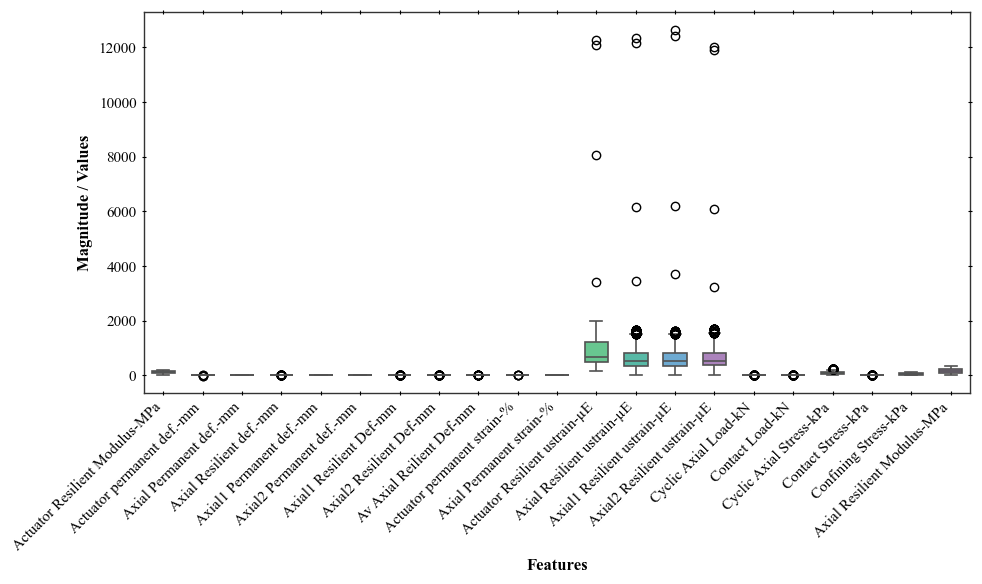

In [8]:
# =========================================================
# 3.1  OUTLIER DETECTION — BOXPLOT
# =========================================================
exclude_cols = METADATA_COLS + [SCBA_COL, THETA_COL]
data_numeric = (data.select_dtypes(include=[np.number])
                    .drop(columns=exclude_cols, errors="ignore"))

fig, ax = plt.subplots(figsize=(10, 6))
flier_props = dict(marker="o", markerfacecolor="none",
                   markeredgecolor="black", markersize=6)

sns.boxplot(data=data_numeric, palette=CUSTOM_PALETTE,
            linewidth=1.2, flierprops=flier_props,
            width=0.6, ax=ax)

apply_academic_spines(ax)
ax.set_ylabel("Magnitude / Values")
ax.set_xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

export_figure(fig, FIGURES_DIR / "Figure_1_Outlier_Detection_Boxplot")
plt.show()


Figure exported (PNG/SVG/PDF): Figure_2_Correlation_Matrix


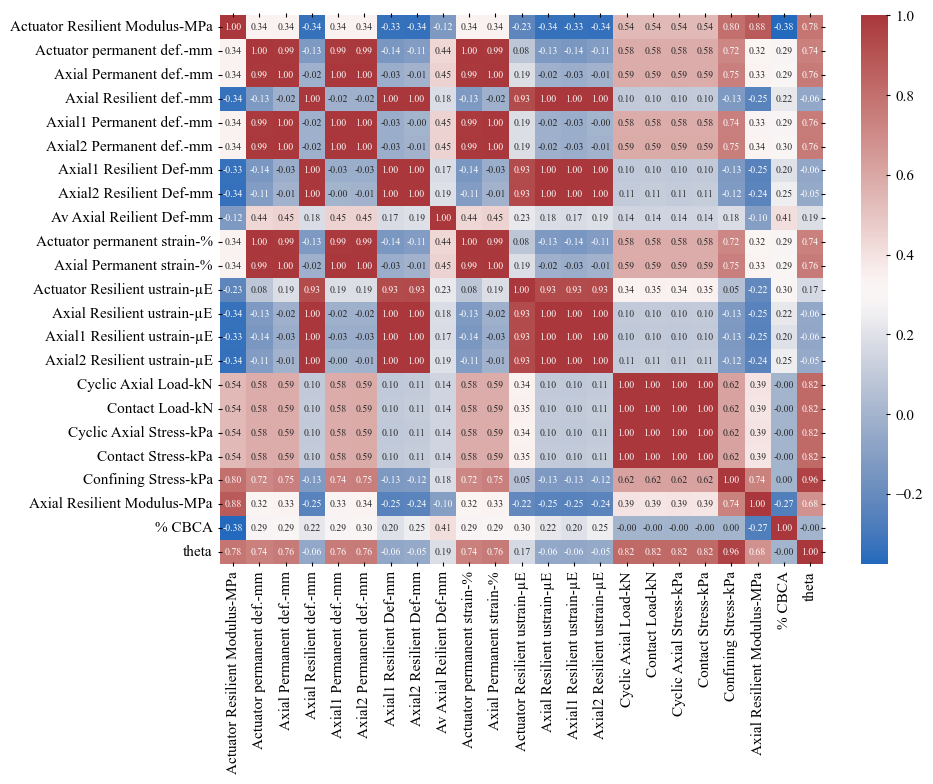

In [9]:
# =========================================================
# 3.2  CORRELATION MATRIX
# =========================================================
feature_cols = [c for c in data.columns if c not in METADATA_COLS]
corr_matrix  = data[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag",
            cbar=True, ax=ax, annot_kws={"size": 7})
ax.grid(False)
plt.tight_layout()

export_figure(fig, FIGURES_DIR / "Figure_2_Correlation_Matrix")
plt.show()


Figure exported (PNG/SVG/PDF): Figure_3_Resilient_Modulus_Classic_Style


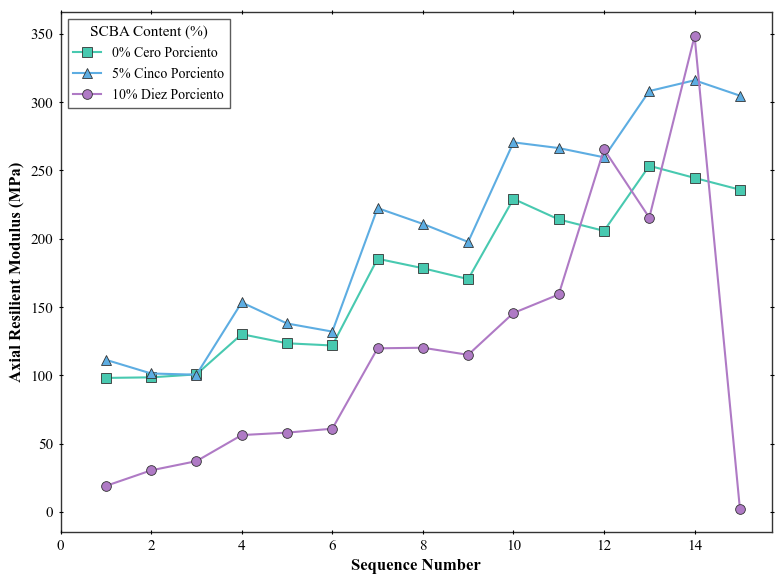

In [10]:
# =========================================================
# 3.3  RESILIENT MODULUS — CLASSIC STYLE
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))
num_categories = data["Experimento"].nunique()

sns.lineplot(
    data=data, x=SEQ_COL, y=TARGET_COL,
    hue="Experimento", style="Experimento",
    markers=MARKERS[:num_categories], dashes=False,
    palette=CUSTOM_PALETTE[:num_categories],
    linewidth=1.5, markersize=7, errorbar=None,
    markeredgecolor="#333333", markeredgewidth=0.6, ax=ax,
)

apply_academic_spines(ax)
ax.set_xlabel("Sequence Number")
ax.set_ylabel("Axial Resilient Modulus (MPa)")
ax.set_xlim(left=0)
ax.legend(title="SCBA Content (%)", title_fontsize=11, fontsize=10,
          frameon=True, edgecolor="#333333", fancybox=False, loc="best")

plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_3_Resilient_Modulus_Classic_Style")
plt.show()


Figure exported (PNG/SVG/PDF): Figure_4_Sequence_Trend


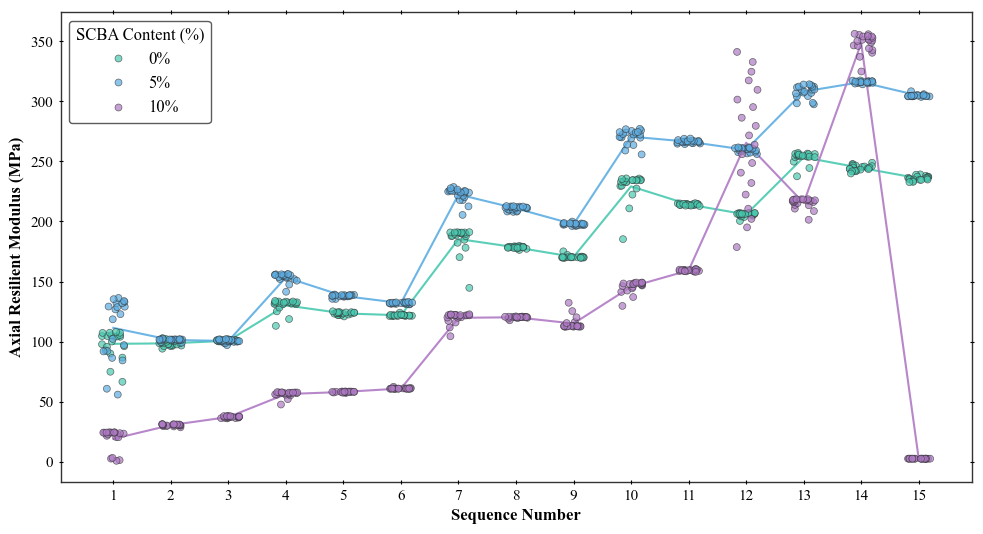

In [11]:
# =========================================================
# 3.4  SEQUENCE TREND (scatter + mean trend lines)
# =========================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.stripplot(
    data=data, x=SEQ_COL, y=TARGET_COL, hue=SCBA_COL,
    palette=COLORS_SCBA, jitter=0.2, alpha=0.7,
    size=5, linewidth=0.5, edgecolor="#333333", ax=ax,
)

seq_units = sorted(data[SEQ_COL].unique())
for scba in [0, 5, 10]:
    sub    = (data[data[SCBA_COL] == scba]
                .groupby(SEQ_COL)[TARGET_COL].mean())
    y_vals = [sub.get(s, np.nan) for s in seq_units]
    ax.plot(range(len(seq_units)), y_vals,
            color=COLORS_SCBA[scba], linewidth=1.5, alpha=0.9)

apply_academic_spines(ax)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles[:3], ["0%", "5%", "10%"],
          title="SCBA Content (%)", loc="upper left",
          frameon=True, edgecolor="#333333")
ax.set_xlabel("Sequence Number")
ax.set_ylabel("Axial Resilient Modulus (MPa)")

plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_4_Sequence_Trend")
plt.show()


### Geotechnical characterization

The resilient modulus of unbound materials is classically modeled as a power-law of the volumetric stress invariant:

$$ M_r = a \cdot \theta^{b}, \qquad \theta = 3\sigma_3 + \Delta\sigma_d $$


Figure exported (PNG/SVG/PDF): Figure_5_Resilient_Modulus_Analysis


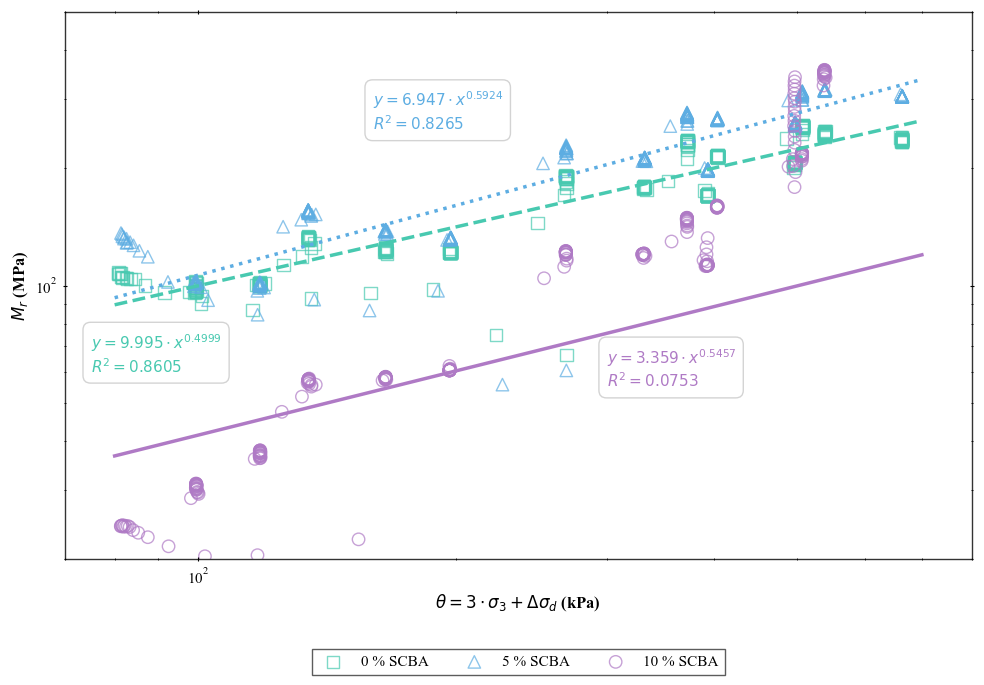

In [12]:
# =========================================================
# 3.5  RESILIENT MODULUS ANALYSIS — IMPACT OF SCBA
# =========================================================
fig, ax = plt.subplots(figsize=(10, 7))
x_range_model = np.geomspace(80, 700, 100)
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.8", alpha=0.85)

text_coords = {0: (75, 60), 5: (160, 250), 10: (300, 55)}
line_styles = {0: "--", 5: ":", 10: "-"}

for idx, scba in enumerate([0, 5, 10]):
    sub = data[data[SCBA_COL] == scba].dropna(subset=[THETA_COL, TARGET_COL])
    x_val, y_val = sub[THETA_COL].values, sub[TARGET_COL].values
    if len(x_val) == 0:
        continue

    c, m = COLORS_SCBA[scba], MARKERS[idx]
    ax.scatter(x_val, y_val, marker=m, edgecolors=c,
               facecolors="none", s=80, alpha=0.7,
               label=f"{scba} % SCBA")

    a, b, r2 = fit_power_law(x_val, y_val)
    ax.plot(x_range_model, a * (x_range_model ** b),
            color=c, linestyle=line_styles[scba], linewidth=2.5)

    pos_x, pos_y = text_coords[scba]
    txt = f"$y = {a:.3f} \\cdot x^{{{b:.4f}}}$\n$R^2 = {r2:.4f}$"
    ax.text(pos_x, pos_y, txt, color=c, fontsize=11,
            fontweight="bold", bbox=bbox_props)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(70, 800); ax.set_ylim(20, 500)
ax.set_xlabel(r"$\theta = 3 \cdot \sigma_3 + \Delta \sigma_d$ (kPa)")
ax.set_ylabel(r"$M_r$ (MPa)")

apply_academic_spines(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3,
          frameon=True, fancybox=False, edgecolor="#333333", fontsize=11)

plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_5_Resilient_Modulus_Analysis")
plt.show()


Figure exported (PNG/SVG/PDF): Figure_6_Permanent_Deformation_Analysis


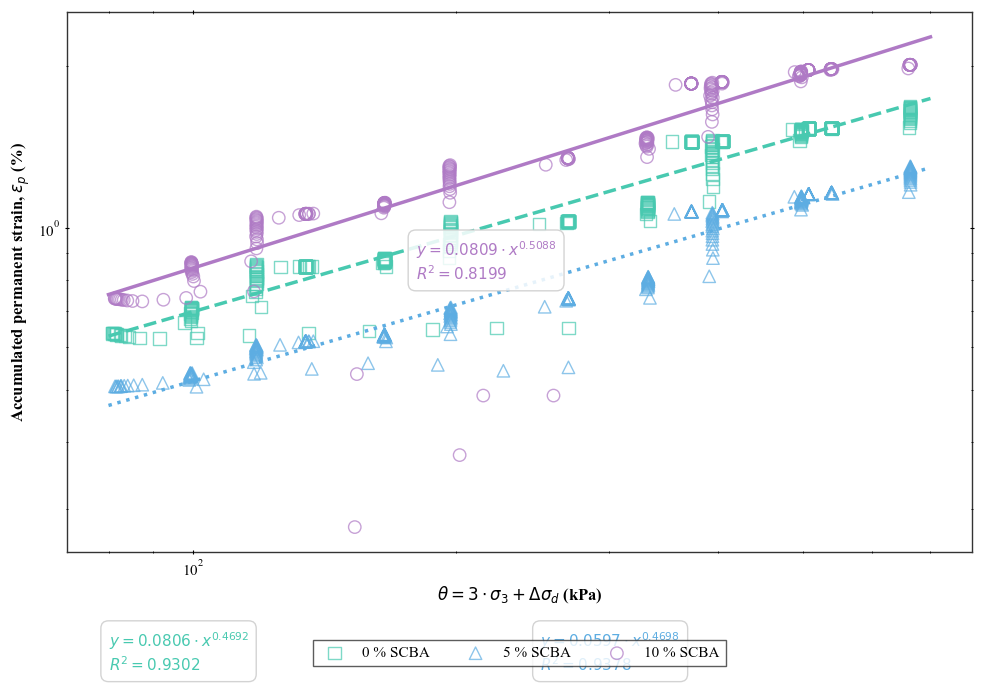

In [13]:
# =========================================================
# 3.6  PERMANENT DEFORMATION ANALYSIS
# =========================================================
fig, ax = plt.subplots(figsize=(10, 7))
x_range_model = np.geomspace(80, 700, 100)
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.8", alpha=0.85)
deform_col = "Axial Permanent strain-%"
text_coords_p = {0: (80, 0.15), 5: (250, 0.15), 10: (180, 0.80)}
line_styles   = {0: "--", 5: ":", 10: "-"}

for idx, scba in enumerate([0, 5, 10]):
    sub = data[data[SCBA_COL] == scba].dropna(subset=[THETA_COL, deform_col])
    x_val, y_val = sub[THETA_COL].values, sub[deform_col].values
    if len(x_val) == 0:
        continue

    c, m = COLORS_SCBA[scba], MARKERS[idx]
    ax.scatter(x_val, y_val, marker=m, edgecolors=c,
               facecolors="none", s=80, alpha=0.7,
               label=f"{scba} % SCBA")

    a, b, r2 = fit_power_law(x_val, y_val)
    ax.plot(x_range_model, a * (x_range_model ** b),
            color=c, linestyle=line_styles[scba], linewidth=2.5)

    pos_x, pos_y = text_coords_p[scba]
    txt = f"$y = {a:.4f} \\cdot x^{{{b:.4f}}}$\n$R^2 = {r2:.4f}$"
    ax.text(pos_x, pos_y, txt, color=c, fontsize=11,
            fontweight="bold", bbox=bbox_props)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\theta = 3 \cdot \sigma_3 + \Delta \sigma_d$ (kPa)")
ax.set_ylabel(r"Accumulated permanent strain, $\epsilon_p$ (%)")

apply_academic_spines(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3,
          frameon=True, fancybox=False, edgecolor="#333333", fontsize=11)

plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_6_Permanent_Deformation_Analysis")
plt.show()


---
<a id="feature-selection"></a>
# 4. Data-quality screening, Leakage Audit & Feature Selection

Feature selection follows four criteria:

0. **Data quality** – invalid readings are documented and removed from the ML analysis (sensitivity with all 900 rows in §8.4).
1. **Target leakage audit** – no variable derived from the axial resilient cycle may be a predictor.
2. **Correlation** with the target and **multicollinearity** (VIF).
3. **Recursive Feature Elimination (RFE)** – exploratory only; the final set is fixed *a priori* on physical grounds so no selection is tuned on test data.

> ⚠️ **Target leakage.** $M_r = \Delta\sigma_d / \varepsilon_r$. Any axial resilient deflection / strain (and the actuator-based $M_r$) is either an input of this
> formula or a measurement of the same quantity. They are excluded; section 4.0b shows numerically that the identity holds exactly.

In [14]:
# =========================================================
# 4.0  DATA-QUALITY SCREENING
# =========================================================
data_raw = data.copy()                       # all 900 records (kept for sensitivity analysis)

# (a) Instrument failure: axial LVDT reads 0 -> Mr computed from it is not physical
zero_strain = data["Axial Resilient def.-mm"].eq(0)
# (b) Load transient: cyclic stress >15 % away from the median of its block (seating cycles)
med_cyc     = data.groupby(BLOCK_COL)["Cyclic Axial Stress-kPa"].transform("median")
off_target  = (data["Cyclic Axial Stress-kPa"] / med_cyc - 1).abs() > 0.15
invalid     = zero_strain | off_target

print(f"(a) zero axial resilient deformation : {int(zero_strain.sum())} rows")
print(f"(b) cyclic stress off target (>15 %) : {int(off_target.sum())} rows")
print(f"    total flagged                     : {int(invalid.sum())} of {len(data)}")

qc = data.loc[invalid, ["N", BLOCK_COL, "Axial Resilient def.-mm", "Cyclic Axial Stress-kPa",
                        TARGET_COL, "Actuator Resilient Modulus-MPa"]]
print("\nFlagged rows summarised by block:")
print(qc.groupby(BLOCK_COL).agg(n=("N", "count"),
                                 N_first=("N", "min"), N_last=("N", "max"),
                                 Mr_axial_mean=(TARGET_COL, "mean"),
                                 Mr_actuator_mean=("Actuator Resilient Modulus-MPa", "mean")).round(2).to_string())

CLEAN_DATA = True        # set False to reproduce the analysis with all 900 rows
if CLEAN_DATA:
    data = data.loc[~invalid].reset_index(drop=True)
print(f"\nRecords used for modelling: {len(data)}  (CLEAN_DATA={CLEAN_DATA})")

(a) zero axial resilient deformation : 20 rows
(b) cyclic stress off target (>15 %) : 5 rows
    total flagged                     : 25 of 900

Flagged rows summarised by block:
          n  N_first  N_last  Mr_axial_mean  Mr_actuator_mean
Block                                                        
10%_S01   5      601     605           6.05              5.93
10%_S15  20      881     900           2.49            145.85

Records used for modelling: 875  (CLEAN_DATA=True)


In [15]:
# =========================================================
# 4.0b  LEAKAGE AUDIT
# =========================================================
# Variables derived from the axial resilient cycle  -> FORBIDDEN as predictors
LEAKAGE_COLS = [
    "Actuator Resilient Modulus-MPa",
    "Axial Resilient def.-mm",
    "Axial1 Resilient Def-mm",
    "Axial2 Resilient Def-mm",
    "Av Axial Reilient Def-mm",
    "Actuator Resilient ustrain-µE",
    "Axial Resilient ustrain-µE",
    "Axial1 Resilient ustrain-µE",
    "Axial2 Resilient ustrain-µE",
]
missing = [c for c in LEAKAGE_COLS if c not in data.columns]
assert not missing, f"Leakage columns not found in the dataset: {missing}"

# Numerical proof:  Mr [MPa] = delta_sigma_d [kPa] / axial resilient strain [micro-strain] * 1e3
mr_from_strain = data["Cyclic Axial Stress-kPa"] / data["Axial Resilient ustrain-µE"] * 1e3
ratio = mr_from_strain / data[TARGET_COL]
print("Ratio  (delta_sigma_d / eps_axial) / Mr_axial :")
print(ratio.describe().round(10).to_string())
print("\n-> The target is an exact algebraic function of the axial resilient strain: using it as a predictor is target leakage.")

Ratio  (delta_sigma_d / eps_axial) / Mr_axial :
count    875.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0

-> The target is an exact algebraic function of the axial resilient strain: using it as a predictor is target leakage.


In [16]:
# =========================================================
# 4.1  CORRELATION WITH TARGET
# =========================================================
candidate_features = [c for c in data.columns
                      if c not in METADATA_COLS + [TARGET_COL]]

corr_with_target = (data[candidate_features]
                    .apply(lambda x: x.corr(data[TARGET_COL]))
                    .abs().sort_values(ascending=False))

print("=== Absolute correlation with the target (Mr) ===")
print(corr_with_target)


=== Absolute correlation with the target (Mr) ===
Actuator Resilient Modulus-MPa    0.937180
Confining Stress-kPa              0.864844
theta                             0.840595
Cyclic Axial Load-kN              0.547497
Cyclic Axial Stress-kPa           0.547497
Contact Load-kN                   0.544722
Contact Stress-kPa                0.544722
Axial2 Permanent def.-mm          0.448861
Axial Permanent strain-%          0.445865
Axial Permanent def.-mm           0.445865
Axial1 Permanent def.-mm          0.442855
Actuator permanent def.-mm        0.436214
Actuator permanent strain-%       0.436214
Axial1 Resilient Def-mm           0.388298
Axial1 Resilient ustrain-µE       0.388298
Axial Resilient def.-mm           0.376062
Axial Resilient ustrain-µE        0.376062
Axial2 Resilient Def-mm           0.362189
Axial2 Resilient ustrain-µE       0.362189
% CBCA                            0.214771
Actuator Resilient ustrain-µE     0.132686
Av Axial Reilient Def-mm          0.076779
dtyp

In [17]:
# =========================================================
# 4.2  MULTICOLLINEARITY (VIF) — EXPLORATORY
# =========================================================
exploratory_features = [
    SCBA_COL, "Confining Stress-kPa", "Cyclic Axial Stress-kPa",
    "Contact Stress-kPa", "Axial Permanent def.-mm",
    "Actuator permanent def.-mm", "Axial Resilient def.-mm",
]

print("=== VIF of the exploratory feature set ===")
print(vif_table(data[exploratory_features].dropna()))


=== VIF of the exploratory feature set ===
                      Feature           VIF
0     Axial Permanent def.-mm  79130.117316
1  Actuator permanent def.-mm  77728.596057
2     Cyclic Axial Stress-kPa   7976.157122
3          Contact Stress-kPa   7899.461104
4        Confining Stress-kPa     39.414520
5                      % CBCA     12.085392
6     Axial Resilient def.-mm      5.679573


In [18]:
# =========================================================
# 4.3  RECURSIVE FEATURE ELIMINATION (RFE) - EXPLORATORY, NO LEAKAGE
# =========================================================
# Ranking only used to inspect which physically admissible variables carry signal.
# The final predictor sets (4.4) are fixed a priori, so nothing is tuned on the test data.
blacklist        = METADATA_COLS + [TARGET_COL] + LEAKAGE_COLS
clean_candidates = [c for c in data.columns if c not in blacklist]

rfe = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=SEED),
          n_features_to_select=5)
rfe.fit(data[clean_candidates], data[TARGET_COL])

rfe_ranking = pd.DataFrame({
    "Feature" : clean_candidates,
    "Selected": rfe.support_,
    "Ranking" : rfe.ranking_,
}).sort_values("Ranking")

print("=== Top-5 features according to RFE (exploratory, no leakage variables) ===")
print(rfe_ranking[rfe_ranking["Selected"]].to_string(index=False))

=== Top-5 features according to RFE (exploratory, no leakage variables) ===
                   Feature  Selected  Ranking
Actuator permanent def.-mm      True        1
   Axial Permanent def.-mm      True        1
      Confining Stress-kPa      True        1
                    % CBCA      True        1
                     theta      True        1


In [19]:
# =========================================================
# 4.4  FINAL PREDICTOR SETS (fixed a priori)
# =========================================================
# M4 (primary, strict)  : only quantities known BEFORE the test (design + applied stresses)
# M3 (sensitivity)      : M4 + accumulated permanent deformation (measured DURING the test, not resilient)
# M2 / M1               : ablation models used in section 8.4 to quantify the effect of leakage
F_BASE       = [SCBA_COL, "Confining Stress-kPa", "Cyclic Axial Stress-kPa"]
FEATURES_M4  = F_BASE + ["Contact Stress-kPa", THETA_COL]
FEATURES_M3  = FEATURES_M4 + ["Axial Permanent def.-mm"]
FEATURES_M2  = F_BASE + ["Axial Permanent def.-mm"]
FEATURES_M1  = FEATURES_M2 + ["Axial Resilient def.-mm"]          # original set (with leakage)

FEATURE_SETS = {"M1": FEATURES_M1, "M2": FEATURES_M2, "M3": FEATURES_M3, "M4": FEATURES_M4}
FINAL_FEATURES = FEATURES_M4

for k in ("M2", "M3", "M4"):
    assert not set(FEATURE_SETS[k]) & set(LEAKAGE_COLS), f"Leakage variable in {k}"
    assert "N" not in FEATURE_SETS[k] and SEQ_COL not in FEATURE_SETS[k]
print("Final (primary) predictors:", FINAL_FEATURES)

print("\n=== VIF of the final set (theta = 3*sigma3 + delta_sigma_d is an exact linear combination) ===")
print(vif_table(data[FINAL_FEATURES]).to_string(index=False))
print("\n=== VIF without theta ===")
print(vif_table(data[[c for c in FINAL_FEATURES if c != THETA_COL]]).to_string(index=False))
print("\nNote: Random Forest predictions are insensitive to collinearity, but feature-importance values "
      "are shared among collinear variables and should be interpreted by group.")

Final (primary) predictors: ['% CBCA', 'Confining Stress-kPa', 'Cyclic Axial Stress-kPa', 'Contact Stress-kPa', 'theta']

=== VIF of the final set (theta = 3*sigma3 + delta_sigma_d is an exact linear combination) ===
                Feature         VIF
   Confining Stress-kPa         inf
                  theta         inf
Cyclic Axial Stress-kPa         inf
     Contact Stress-kPa 7496.690211
                 % CBCA    1.022934

=== VIF without theta ===
                Feature         VIF
Cyclic Axial Stress-kPa 7530.386986
     Contact Stress-kPa 7496.690211
   Confining Stress-kPa    1.644677
                 % CBCA    1.022934

Note: Random Forest predictions are insensitive to collinearity, but feature-importance values are shared among collinear variables and should be interpreted by group.


---
<a id="data-prep"></a>
# 5. Data Preparation (block-wise split)

**Hold-out:** `GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)` grouped by `Block` (SCBA level × sequence). No block contributes rows to both subsets.
**Tuning / CV:** `GroupKFold(n_splits=5)` on the training blocks.
Random Forest is scale-invariant; scaling is applied inside the pipelines of the SVR and ANN only, so nothing is fitted on validation/test data.

> Limitation: the test blocks still belong to the same three specimens (they test interpolation between stress states).
> Generalisation to unseen sequences and unseen SCBA levels is assessed separately in §8.4.

In [20]:
# =========================================================
# 5.  BLOCK-WISE SPLIT
# =========================================================
X = data[FINAL_FEATURES]
y = data[TARGET_COL]
groups = data[BLOCK_COL]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

# Mandatory independence check
assert set(groups_train).isdisjoint(set(groups_test)), "Block shared between train and test"

print(f"Train: {len(X_train)} rows / {groups_train.nunique()} blocks")
print(f"Test : {len(X_test)} rows / {groups_test.nunique()} blocks")
print("\nTest blocks per SCBA level:")
print(data.iloc[test_idx].groupby(SCBA_COL)[BLOCK_COL].nunique().to_string())
print("\nTest blocks:", sorted(groups_test.unique()))

Train: 695 rows / 35 blocks
Test : 180 rows / 9 blocks

Test blocks per SCBA level:
% CBCA
0.0     3
5.0     4
10.0    2

Test blocks: ['0%_S05', '0%_S09', '0%_S13', '10%_S10', '10%_S11', '5%_S06', '5%_S08', '5%_S09', '5%_S12']


---
<a id="model-training"></a>
# 6. Model Training & Comparison

Three model families are compared with **5-fold grouped cross-validation** (`GroupKFold`, groups = `Block`) on the training set only:

1. **Random Forest Regressor**
2. **Support Vector Regressor (RBF kernel, scaled inputs and target)**
3. **Artificial Neural Network** (64-32, ReLU, Adam)

In [21]:
# =========================================================
# 6.1  GROUPED CV COMPARISON (RF / SVR / ANN)
# =========================================================
assert groups_train.nunique() >= 5, "Fewer than 5 blocks in training"
gkf = GroupKFold(n_splits=5)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=SEED),
    "SVR (RBF)"    : build_svr(),
    "ANN (64-32)"  : build_mlp(),
}
cmp_rows = []
for name, model in models.items():
    rmse = -cross_val_score(model, X_train, y_train, groups=groups_train, cv=gkf,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
    r2   =  cross_val_score(model, X_train, y_train, groups=groups_train, cv=gkf,
                            scoring="r2", n_jobs=-1)
    cmp_rows.append({"Model": name,
                     "CV RMSE (MPa)": rmse.mean(), "RMSE sd": rmse.std(),
                     "CV R2": r2.mean(), "R2 sd": r2.std()})
cv_comparison = pd.DataFrame(cmp_rows).round(3)
print("=== Grouped 5-fold CV on training blocks (default hyper-parameters) ===")
print(cv_comparison.to_string(index=False))
cv_comparison.to_csv(REPORTS_DIR / "model_comparison_groupcv.csv", index=False)

=== Grouped 5-fold CV on training blocks (default hyper-parameters) ===
        Model  CV RMSE (MPa)  RMSE sd  CV R2  R2 sd
Random Forest         28.292    7.814  0.880  0.086
    SVR (RBF)         42.656    9.371  0.751  0.090
  ANN (64-32)         34.366    8.322  0.827  0.096


Figure exported (PNG/SVG/PDF): Figure_7_ANN_Training_Loss


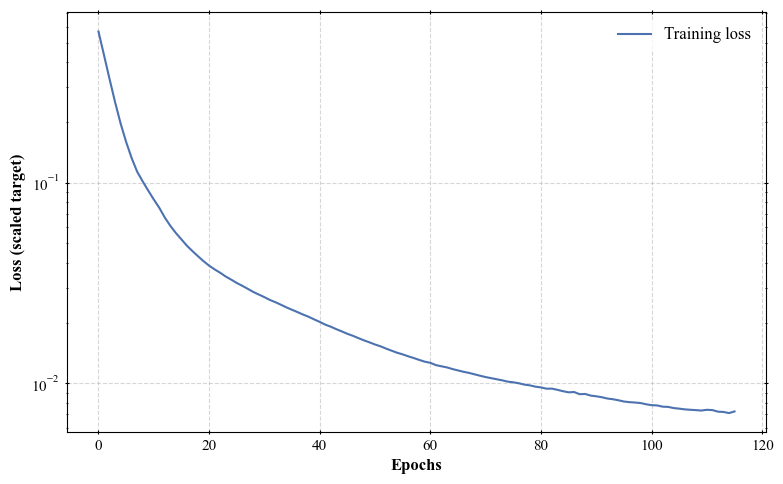

In [22]:
# =========================================================
# 6.3  ANN - TRAINING LOSS (final fit on the training blocks)
# =========================================================
ann_model = build_mlp().fit(X_train, y_train)
loss_curve = ann_model.regressor_.named_steps["mlp"].loss_curve_      # loss on the scaled target

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(loss_curve, label="Training loss", color="#4c72b0", linewidth=1.5)
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss (scaled target)")
ax.set_yscale("log")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(frameon=True, facecolor="white", edgecolor="none")
plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_7_ANN_Training_Loss", dpi=300)
plt.show()

---
<a id="hyperparameter-tuning"></a>
# 7. Hyperparameter Tuning

The Random Forest (the model studied in the manuscript) is tuned with `GridSearchCV` (5-fold `GroupKFold`, groups = `Block`, scoring = negative RMSE) over:

| Hyperparameter | Values |
|---|---|
| `n_estimators` | 50, 100, 200 |
| `max_features` | `sqrt`, `log2`, `None` |
| `max_depth` | 10, 20, `None` |
| `min_samples_split` | 2, 5 |

→ 3 × 3 × 3 × 2 = **54 combinations × 5 folds = 270 fits** (+1 refit). Only these **four** hyperparameters are tuned; `min_samples_leaf`, `bootstrap`, `criterion` and all others keep scikit-learn defaults and `random_state = 42`.

In [23]:
# =========================================================
# 7.  HYPERPARAMETER SEARCH - GridSearchCV with GroupKFold
# =========================================================
param_grid = {
    "n_estimators"     : [50, 100, 200],
    "max_features"     : ["sqrt", "log2", None],
    "max_depth"        : [10, 20, None],
    "min_samples_split": [2, 5],
}
n_comb = len(ParameterGrid(param_grid))
print(f"{n_comb} combinations x 5 folds = {n_comb * 5} fits")

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    param_grid,
    cv=GroupKFold(n_splits=5),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
)
grid_search.fit(X_train, y_train, groups=groups_train)

best_rf = grid_search.best_estimator_
print("Best hyper-parameters :", grid_search.best_params_)
print(f"Best grouped-CV RMSE  : {-grid_search.best_score_:.4f} MPa")

final_params = best_rf.get_params()
report_keys = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf",
               "max_features", "bootstrap", "random_state", "criterion"]
final_hyperparams = {k: final_params[k] for k in report_keys}
print("\n=== Final hyper-parameters for the manuscript ===")
for k, v in final_hyperparams.items():
    print(f"  {k:20s} = {v}")

pd.DataFrame(grid_search.cv_results_).to_csv(REPORTS_DIR / "gridsearch_cv_results.csv", index=False)

54 combinations x 5 folds = 270 fits
Best hyper-parameters : {'max_depth': 10, 'max_features': None, 'min_samples_split': 5, 'n_estimators': 50}
Best grouped-CV RMSE  : 28.0293 MPa

=== Final hyper-parameters for the manuscript ===
  n_estimators         = 50
  max_depth            = 10
  min_samples_split    = 5
  min_samples_leaf     = 1
  max_features         = None
  bootstrap            = True
  random_state         = 42
  criterion            = squared_error


---
<a id="final-evaluation"></a>
# 8. Final Evaluation

The tuned model is now evaluated **once** on the held-out test set.


In [24]:
# =========================================================
# 8.1  FINAL METRICS ON THE HELD-OUT TEST BLOCKS
# =========================================================
y_pred = best_rf.predict(X_test)
m_test = reg_metrics(y_test, y_pred)
r2, rmse, mae = m_test["R2"], m_test["RMSE"], m_test["MAE"]

print(f"Test R2   : {r2:.4f}")
print(f"Test RMSE : {rmse:.4f} MPa")
print(f"Test MAE  : {mae:.4f} MPa")
print(f"({len(y_test)} rows, {groups_test.nunique()} blocks never seen during training/tuning)")
print("\nCAUTION: with only 9 test blocks from 3 specimens this single hold-out has very high variance;")
print("the representative figure is the repeated block hold-out (V1, mean +/- sd) and V2/V3 in section 8.4.")

Test R2   : -0.1372
Test RMSE : 50.4378 MPa
Test MAE  : 32.9297 MPa
(180 rows, 9 blocks never seen during training/tuning)

CAUTION: with only 9 test blocks from 3 specimens this single hold-out has very high variance;
the representative figure is the repeated block hold-out (V1, mean +/- sd) and V2/V3 in section 8.4.


In [ ]:
# =========================================================
# 8.1b  SHARED HELPER: tuned Random Forest as a predictor function
# =========================================================
# (defined here so that sections 8.2 and 8.4 can be run top-to-bottom: "Restart & Run All")
RF_PARAMS = {**grid_search.best_params_, "random_state": SEED}

def rf_predict(feats):
    def _p(tr, te):
        return RandomForestRegressor(**RF_PARAMS).fit(tr[feats], tr[TARGET_COL]).predict(te[feats])
    return _p

Figure exported (PNG/SVG/PDF): Figure_8_Measured_vs_Predicted


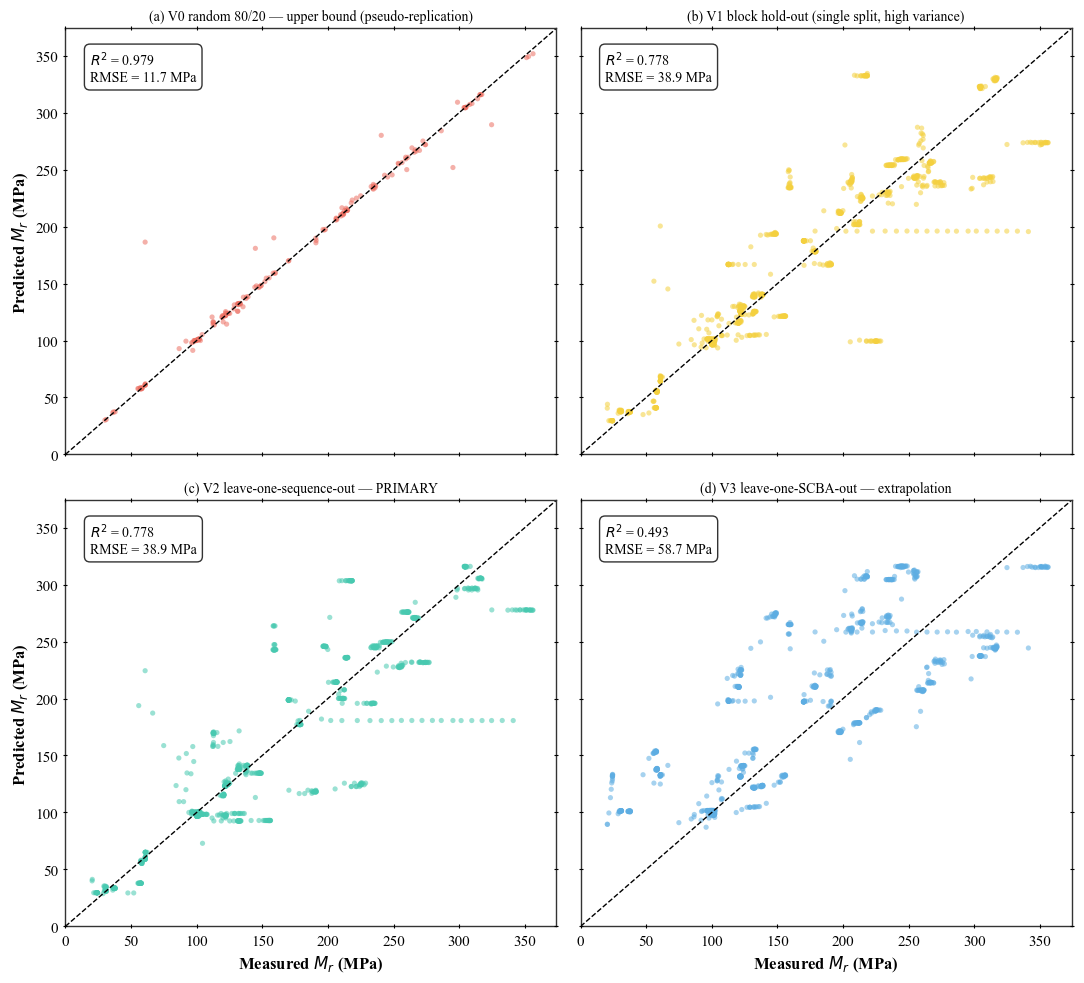

In [36]:
# =========================================================
# 8.2  MEASURED vs PREDICTED UNDER THE FOUR VALIDATION SCHEMES
# =========================================================
rf_pred = rf_predict(FEATURE_SETS["M4"])

def get_preds(df, predictor, scheme):
    df = df.reset_index(drop=True)
    pred = np.full(len(df), np.nan)
    if scheme == "V0":
        tr, te = train_test_split(np.arange(len(df)), test_size=0.20, random_state=SEED)
        pred[te] = predictor(df.iloc[tr], df.iloc[te])
    elif scheme == "V1":
        
        preds_all = []
        for tr, te in GroupShuffleSplit(n_splits=20, test_size=0.20,
                                        random_state=SEED).split(df, groups=df[BLOCK_COL]):
            p = np.full(len(df), np.nan)
            p[te] = predictor(df.iloc[tr], df.iloc[te])
            preds_all.append(p)
        pred = np.nanmean(np.vstack(preds_all), axis=0)
    elif scheme == "V2":
        for tr, te in LeaveOneGroupOut().split(df, groups=df[SEQ_COL]):
            pred[te] = predictor(df.iloc[tr], df.iloc[te])
    elif scheme == "V3":
        for tr, te in LeaveOneGroupOut().split(df, groups=df[SCBA_COL]):
            pred[te] = predictor(df.iloc[tr], df.iloc[te])
    return pred

fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharex=True, sharey=True)
lim = [0, data[TARGET_COL].max() * 1.05]

schemes = [
    ("(a) V0 random 80/20 — upper bound (pseudo-replication)",
     "V0", "#EC7063"),
    ("(b) V1 block hold-out (single split, high variance)",
     "V1", "#F4D03F"),
    ("(c) V2 leave-one-sequence-out — PRIMARY",
     "V2", "#48C9B0"),
    ("(d) V3 leave-one-SCBA-out — extrapolation",
     "V3", "#5DADE2"),
]

for ax, (title, key, color) in zip(axes.ravel(), schemes):
    p = get_preds(data, rf_pred, key)
    mask = ~np.isnan(p)
    yv = data.loc[mask, TARGET_COL].values
    pv = p[mask]
    m = reg_metrics(yv, pv)

    ax.scatter(yv, pv, s=14, alpha=0.55, color=color, edgecolor="none")
    ax.plot(lim, lim, "k--", linewidth=1, zorder=1)

    txt = f"$R^2$ = {m['R2']:.3f}\nRMSE = {m['RMSE']:.1f} MPa"
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=10,
            va="top", bbox=dict(boxstyle="round,pad=0.4",
                                facecolor="white", edgecolor="#333333"))

    ax.set_title(title, fontsize=10)
    ax.set_xlim(lim); ax.set_ylim(lim)
    apply_academic_spines(ax)

for ax in axes[-1, :]:
    ax.set_xlabel("Measured $M_r$ (MPa)")
for ax in axes[:, 0]:
    ax.set_ylabel("Predicted $M_r$ (MPa)")

plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_8_Measured_vs_Predicted")
plt.show()

Figure exported (PNG/SVG/PDF): Figure_9_Feature_Importance


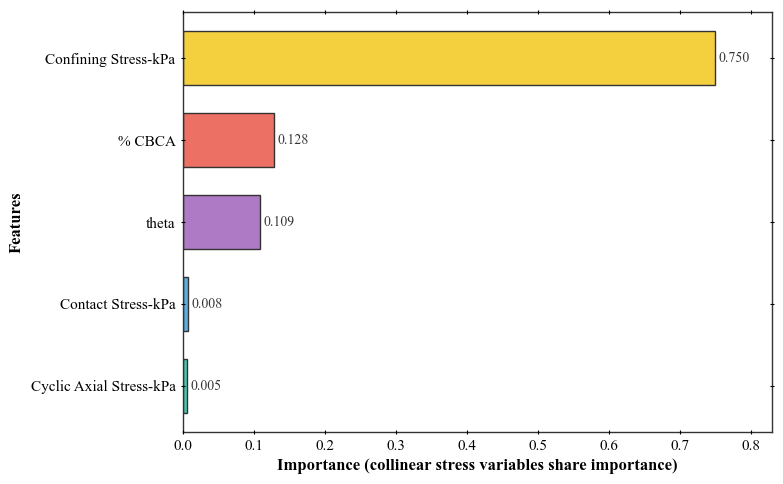

In [26]:
# =========================================================
# 8.3  FEATURE IMPORTANCE
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5))

df_imp = (pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "Importance": best_rf.feature_importances_,
}).sort_values("Importance", ascending=True))

bars = ax.barh(df_imp["Feature"], df_imp["Importance"],
               color=CUSTOM_PALETTE[:len(df_imp)],
               edgecolor="#333333", linewidth=1.0, height=0.65)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f"{width:.3f}", va="center", ha="left",
            fontsize=10, color="#333333")

apply_academic_spines(ax)
ax.set_xlim(0, df_imp["Importance"].max() + 0.08)
ax.set_xlabel("Importance (collinear stress variables share importance)")
ax.set_ylabel("Features")
plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_9_Feature_Importance")
plt.show()

### 8.4 Robustness audit: leakage, dependence and extrapolation

Four validation schemes are applied to the four predictor sets (M1–M4) with the tuned Random Forest hyper-parameters of §7 (same for all sets, for comparability):

| Scheme | Description | What it measures |
|---|---|---|
| **V0** | random row-wise 80/20 split (protocol of the original manuscript) | *upper bound only* – neighbouring readings of the same series are in train and test (pseudo-replication) |
| **V1** | block-wise hold-out, 20 repetitions (mean ± sd) | interpolation between unseen blocks of the same specimens |
| **V2** | leave-one-sequence-out (15 folds, pooled) — **primary scheme** | prediction at a stress state not tested before, *same three specimens* |
| **V3** | leave-one-SCBA-level-out (3 folds, pooled) | prediction for an unseen specimen / SCBA content (extrapolation) |

Two naive references are added: the mean $M_r$ per block (V0 only; meaningless for unseen blocks) and the classical $k$–$\theta$ power law $M_r = a\theta^b$ (per SCBA level when available).

In [27]:
# =========================================================
# 8.4  ROBUSTNESS AUDIT (M1..M4 x V0..V3 + baselines)
# =========================================================
RF_PARAMS = {**grid_search.best_params_, "random_state": SEED}

def rf_predict(feats):
    def _p(tr, te):
        return RandomForestRegressor(**RF_PARAMS).fit(tr[feats], tr[TARGET_COL]).predict(te[feats])
    return _p

def kth_predict(tr, te):
    """Classical k-theta law  Mr = a * theta^b  (per SCBA level if present in train, pooled otherwise)."""
    fit = lambda d: np.polyfit(np.log(d[THETA_COL]), np.log(d[TARGET_COL]), 1)
    pooled = fit(tr)
    coefs = {c: fit(g) for c, g in tr.groupby(SCBA_COL)}
    return np.array([np.exp(np.polyval(coefs.get(c, pooled), np.log(t)))
                     for c, t in zip(te[SCBA_COL], te[THETA_COL])])

def block_mean_predict(tr, te):
    m = tr.groupby(BLOCK_COL)[TARGET_COL].mean()
    return te[BLOCK_COL].map(m).to_numpy()          # NaN for unseen blocks

def evaluate(df, predictor, scheme):
    df = df.reset_index(drop=True)
    yv = df[TARGET_COL].to_numpy()
    if scheme == "V0 random 80/20":
        tr, te = train_test_split(np.arange(len(df)), test_size=0.20, random_state=SEED)
        p = predictor(df.iloc[tr], df.iloc[te])
        ok = ~np.isnan(p)
        return {**reg_metrics(yv[te][ok], p[ok]), "R2_sd": np.nan}
    if scheme == "V1 block hold-out x20":
        res = []
        for tr, te in GroupShuffleSplit(n_splits=20, test_size=0.20, random_state=SEED).split(df, groups=df[BLOCK_COL]):
            p = predictor(df.iloc[tr], df.iloc[te])
            if np.isnan(p).any():
                return {"R2": np.nan, "RMSE": np.nan, "MAE": np.nan, "R2_sd": np.nan}
            res.append(reg_metrics(yv[te], p))
        r = pd.DataFrame(res)
        return {"R2": r.R2.mean(), "RMSE": r.RMSE.mean(), "MAE": r.MAE.mean(), "R2_sd": r.R2.std()}
    gcol = SEQ_COL if scheme.startswith("V2") else SCBA_COL
    pred = np.full(len(df), np.nan)
    for tr, te in LeaveOneGroupOut().split(df, groups=df[gcol]):
        pred[te] = predictor(df.iloc[tr], df.iloc[te])
    if np.isnan(pred).any():
        return {"R2": np.nan, "RMSE": np.nan, "MAE": np.nan, "R2_sd": np.nan}
    return {**reg_metrics(yv, pred), "R2_sd": np.nan}

SCHEMES = ["V0 random 80/20", "V1 block hold-out x20", "V2 leave-one-sequence-out", "V3 leave-one-SCBA-out"]

jobs = [(f"{k} ({len(v)} feat.)", data, rf_predict(v)) for k, v in FEATURE_SETS.items()]
jobs += [("Baseline: k-theta law", data, kth_predict),
         ("Baseline: block mean", data, block_mean_predict)]
if CLEAN_DATA:   # sensitivity: same primary model on all 900 rows (incl. flagged readings)
    jobs += [("M4 - all 900 rows", data_raw, rf_predict(FEATURES_M4)),
             ("Baseline k-theta - all 900 rows", data_raw, kth_predict)]

audit_rows = []
for name, df_, pred_fn in jobs:
    for sch in SCHEMES:
        audit_rows.append({"Model": name, "Scheme": sch, **evaluate(df_, pred_fn, sch)})
audit_df = pd.DataFrame(audit_rows)

audit_tbl = audit_df.pivot(index="Model", columns="Scheme", values="R2")[SCHEMES]
order = [j[0] for j in jobs]
print("=== R2 by model and validation scheme ===")
print(audit_tbl.loc[order].round(3).to_string())
print("\n=== RMSE (MPa) ===")
print(audit_df.pivot(index="Model", columns="Scheme", values="RMSE")[SCHEMES].loc[order].round(2).to_string())
v1 = audit_df[audit_df.Scheme == "V1 block hold-out x20"].set_index("Model")
print("\n=== V1: R2 standard deviation across the 20 block splits ===")
print(v1.loc[[o for o in order if o in v1.index], "R2_sd"].round(3).to_string())

audit_df.round(4).to_csv(REPORTS_DIR / "robustness_audit.csv", index=False)
print(f"\nExported -> {REPORTS_DIR / 'robustness_audit.csv'}")

=== R2 by model and validation scheme ===
Scheme                           V0 random 80/20  V1 block hold-out x20  V2 leave-one-sequence-out  V3 leave-one-SCBA-out
Model                                                                                                                    
M1 (5 feat.)                               0.995                  0.759                      0.779                  0.434
M2 (4 feat.)                               0.996                  0.821                      0.833                  0.405
M3 (6 feat.)                               0.984                  0.746                      0.777                  0.469
M4 (5 feat.)                               0.979                  0.702                      0.778                  0.493
Baseline: k-theta law                      0.866                  0.805                      0.844                  0.466
Baseline: block mean                       0.988                    NaN                        NaN      

 Held-out % CBCA    R2   RMSE    MAE
             0.0 0.456 40.564 33.369
             5.0 0.709 41.307 34.560
            10.0 0.159 85.540 81.733
Figure exported (PNG/SVG/PDF): Figure_10_Validation_Schemes


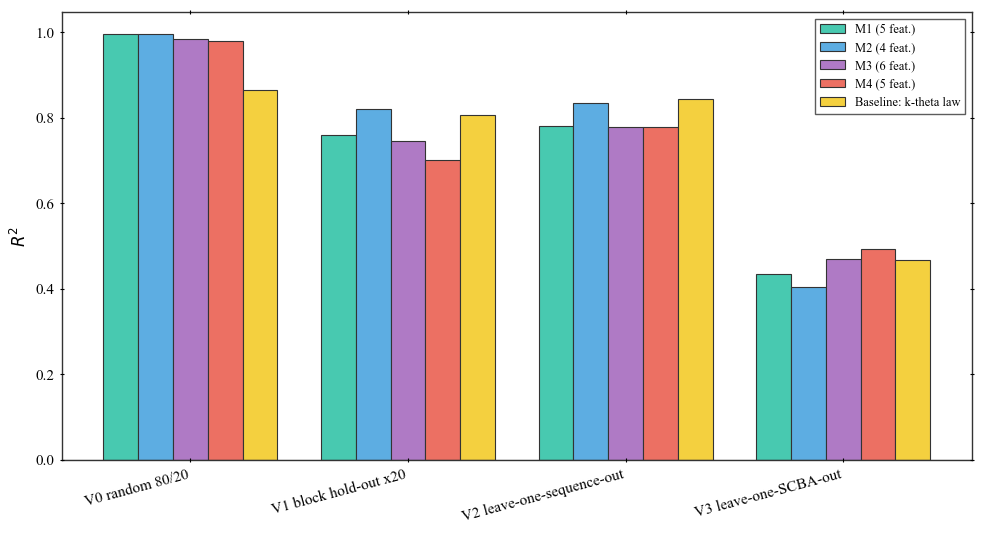

In [28]:
# =========================================================
# 8.4b  LEAVE-ONE-SCBA-LEVEL-OUT: DETAIL PER HELD-OUT LEVEL (primary model M4)
# =========================================================
det = []
for tr, te in LeaveOneGroupOut().split(data, groups=data[SCBA_COL]):
    d_tr, d_te = data.iloc[tr], data.iloc[te]
    p = rf_predict(FEATURES_M4)(d_tr, d_te)
    det.append({"Held-out % CBCA": d_te[SCBA_COL].iloc[0], **reg_metrics(d_te[TARGET_COL], p)})
print(pd.DataFrame(det).round(3).to_string(index=False))

# ---- Figure 10: R2 of M1..M4 and k-theta under each scheme ----------------
plot_models = [o for o in order if o.startswith(("M1", "M2", "M3", "M4 (")) or o == "Baseline: k-theta law"]
fig, ax = plt.subplots(figsize=(10, 5.5))
w = 0.8 / len(plot_models)
for i, mname in enumerate(plot_models):
    vals = audit_tbl.loc[mname, SCHEMES].values.astype(float)
    ax.bar(np.arange(len(SCHEMES)) + i * w, vals, width=w, label=mname,
           color=CUSTOM_PALETTE[i % len(CUSTOM_PALETTE)], edgecolor="#333333", linewidth=0.8)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xticks(np.arange(len(SCHEMES)) + w * (len(plot_models) - 1) / 2)
ax.set_xticklabels(SCHEMES, rotation=15, ha="right")
ax.set_ylabel(r"$R^2$")
ax.legend(frameon=True, edgecolor="#333333", fancybox=False, fontsize=9)
apply_academic_spines(ax)
plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_10_Validation_Schemes", dpi=300)
plt.show()

### 8.5 Interpretation and limitations

Reading the table of §8.4 (values are for the screened data, `CLEAN_DATA=True`; re-running reproduces them with `SEED = 42`):

1. **The original figure (R² ≈ 0.997) is reproduced only under V0.** With a random row-wise split all predictor sets, including the strict set M4 (no resilient-cycle variable), reach R² ≈ 0.98–0.996, and even a *block-mean* lookup with no learning reaches ≈ 0.99. The high value is therefore explained mainly by **dependence between neighbouring readings of the same specimen**, not by model skill.
2. **Removing the axial resilient deflection (M1 → M2) does not lower the score** (V0 ≈ 0.995 → 0.996; V1 ≈ 0.76 → 0.82). The variable is formally leakage (§4.0b: $M_r = \Delta\sigma_d/\varepsilon_r$ holds exactly), but the Random Forest does not exploit it in a way that drives the headline R²; the inflation comes from the split.
3. **Under validation that keeps blocks intact the R² is lower and very variable:** V1 ≈ 0.70–0.82 with a standard deviation of 0.15–0.30 across splits; V2 (unseen stress state) ≈ 0.78–0.83. A single 9-block hold-out (§8.1, seed 42) can even give a negative R² — this is a property of having only 3 specimens, not a bug. Report V1/V2 (mean ± sd), not a single split.
4. **The classical $k$–$\theta$ law is as good as, or better than, the Random Forest** under V1 and V2 (R² ≈ 0.81 and 0.84 vs ≈ 0.70 and 0.78 for M4). The Random Forest only clearly outperforms it under the (invalid) random split. Claims that the ML model improves on the constitutive model are **not supported** by this validation and should be removed or qualified.
5. **Extrapolation to an unseen SCBA level (V3) is poor** (R² ≈ 0.4–0.5; ≈ 0.16 when the 10 % level is held out). With one specimen per level, the model cannot be claimed to generalise to new specimens or new SCBA contents.
6. **Data quality matters:** 25 readings (LVDT reading zero in sequence 15 of the 10 % specimen; load not yet at target in the first readings of sequence 1 of that specimen) distort the target (Mr ≈ 0.7–22 MPa, while the actuator-based value is ≈ 145 MPa in sequence 15). Keeping them lowers V1/V2 R² of M4 from ≈ 0.70/0.78 to ≈ 0.30/0.43 (row "M4 – all 900 rows"). The decision to exclude them must be confirmed against the laboratory records and reported.

**Limitations.** Three physical specimens (one per SCBA level); test blocks share specimens with training blocks; `Contact Stress` is almost proportional to `Cyclic Axial Stress` (VIF > 7 000) and θ is an exact linear combination of the two applied stresses. The model should be presented as a descriptive surrogate **inside the tested stress range**, and the manuscript should state that replicate specimens are needed to claim generalisation.

---
### 8.6 Model-improvement study

Legitimate ways to improve the model without touching the validation: target transformation, regularisation, physically motivated features, alternative algorithms and physics + ML hybrids. Any quantity derived from the target (power-law fits) is estimated **inside each training fold** to avoid leakage.

                                    Modelo    V0    V1  V1_sd  V1_rmse    V2  V2_rmse    V3  V3_rmse ΔV1 vs k-θ (mean±sd) ΔV1 vs MEPDG
                            k-θ (per CBCA) 0.866 0.805  0.129   29.855 0.844   32.540 0.466   60.289         +0.000±0.000 -0.036±0.067
                MEPDG universal (per CBCA) 0.882 0.841  0.141   26.387 0.856   31.300 0.500   58.334         +0.036±0.067 +0.000±0.000
       RF original tuned (raw, base feat.) 0.979 0.702  0.302   32.811 0.778   38.906 0.493   58.727         -0.103±0.229 -0.139±0.254
          RF regularised (raw, base feat.) 0.969 0.709  0.215   35.351 0.795   37.389 0.521   57.108         -0.097±0.137 -0.132±0.167
               RF regularised + log target 0.975 0.745  0.162   33.791 0.807   36.281 0.530   56.595         -0.061±0.093 -0.096±0.116
         RF regularised + log + ext. feat. 0.968 0.674  0.260   36.408 0.801   36.784 0.523   57.020         -0.132±0.173 -0.167±0.202
                 HistGB + log + ext. feat. 0.976 0.789 

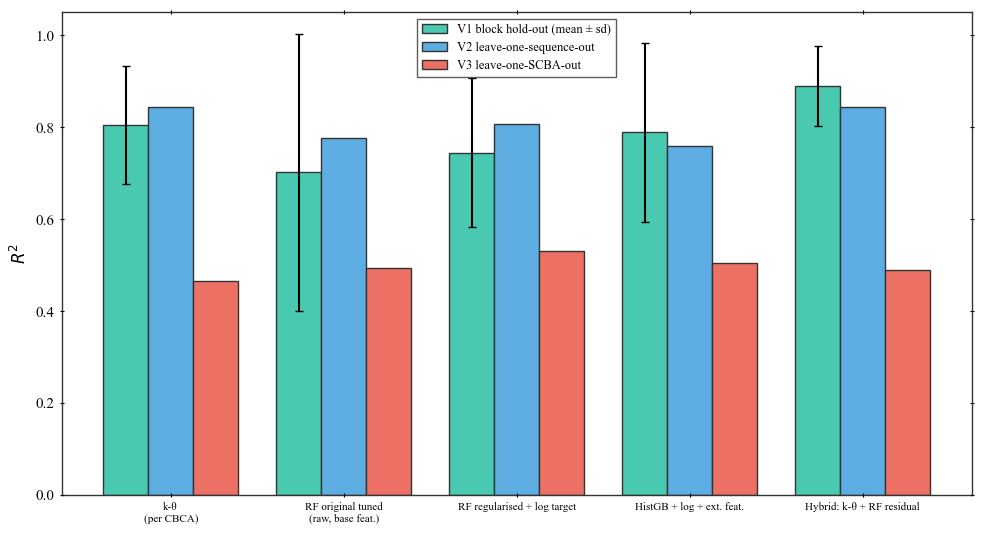

In [29]:
# =========================================================
# 8.6  MODEL-IMPROVEMENT STUDY (pre-specified candidates, NO tuning on the evaluation folds)
# =========================================================
# Everything that uses the target (power-law / MEPDG fits, log transform) is fitted INSIDE each
# training fold. Hyper-parameters below are fixed a priori (not tuned on V1/V2/V3).
import time
from sklearn.ensemble import HistGradientBoostingRegressor

d = data.copy()
d["cb"], d["seq"], d["block"] = d[SCBA_COL], d[SEQ_COL], d[BLOCK_COL]
C, Y, K, T = "Confining Stress-kPa", "Cyclic Axial Stress-kPa", "Contact Stress-kPa", TARGET_COL
PA = 101.325
d["tau_oct"] = np.sqrt(2) / 3 * d[Y]
d["theta_log"] = np.log(d.theta)
d["theta_sqrt"] = np.sqrt(d.theta)
d["theta2"] = d.theta ** 2
d["ratio_s3_dsd"] = d[C] / d[Y]
d["contact_ratio"] = d[K] / d[Y]
d["ln_tau"] = np.log(d.tau_oct / PA + 1)

BASE = ["cb", C, Y, K, "theta"]
EXT = BASE + ["theta_log", "theta_sqrt", "ratio_s3_dsd"]

# ---------- physics models (fitted inside each training fold) ----------
def design(df, kind):
    lt = np.log(df.theta / PA)
    if kind == "ktheta":
        return np.c_[np.ones(len(df)), lt]
    return np.c_[np.ones(len(df)), lt, np.log(df.tau_oct / PA + 1)]       # MEPDG universal

def fit_phys(tr, kind):
    coefs = {}
    def ols(g):
        A = design(g, kind); return np.linalg.lstsq(A, np.log(g[T].values), rcond=None)[0]
    pooled = ols(tr)
    for c, g in tr.groupby("cb"): coefs[c] = ols(g)
    return coefs, pooled

def phys_log(te, model, kind):
    coefs, pooled = model
    out = np.empty(len(te))
    for c in te.cb.unique():
        m = (te.cb == c).values
        out[m] = design(te[m], kind) @ coefs.get(c, pooled)
    return out

# ---------- candidate predictors: f(train_df, test_df) -> prediction (MPa) ----------
RF_OLD = dict(n_estimators=50, max_depth=10, min_samples_split=5, max_features=None, random_state=SEED)
RF_REG = dict(n_estimators=500, max_depth=8, min_samples_leaf=5, min_samples_split=10,
              max_features=0.5, max_samples=0.7, random_state=SEED, n_jobs=-1)

def rf_raw(feats, params):
    return lambda tr, te: RandomForestRegressor(**params).fit(tr[feats], tr[T]).predict(te[feats])
def rf_log(feats, params):
    return lambda tr, te: np.exp(RandomForestRegressor(**params).fit(tr[feats], np.log(tr[T])).predict(te[feats]))
def hgb_log(feats):
    return lambda tr, te: np.exp(HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=300,
                                 min_samples_leaf=20, l2_regularization=1.0, random_state=SEED)
                                 .fit(tr[feats], np.log(tr[T])).predict(te[feats]))
def svr_log(feats):
    def f(tr, te):
        m = Pipeline([("s", StandardScaler()), ("svr", SVR(C=10, epsilon=0.05, gamma="scale"))])
        ys = np.log(tr[T]); mu, sd = ys.mean(), ys.std()
        return np.exp(m.fit(tr[feats], (ys - mu) / sd).predict(te[feats]) * sd + mu)
    return f
def phys_only(kind):
    return lambda tr, te: np.exp(phys_log(te, fit_phys(tr, kind), kind))
def hybrid(kind, feats, params, use_feature=False):
    def f(tr, te):
        pm = fit_phys(tr, kind)
        tr_, te_ = tr.copy(), te.copy()
        tr_["phys"] = phys_log(tr, pm, kind); te_["phys"] = phys_log(te, pm, kind)
        F = feats + (["phys"] if use_feature else [])
        res = np.log(tr_[T]) - tr_["phys"]
        rf = RandomForestRegressor(**params).fit(tr_[F], res)
        return np.exp(te_["phys"] + rf.predict(te_[F]))
    return f
def block_median_train(inner, feats):
    def f(tr, te):
        agg = tr.groupby("block").agg({**{c: "median" for c in set(feats + [T, "theta", "tau_oct", "cb"])}}).reset_index()
        agg["block"] = agg["block"]
        return inner(agg, te)
    return f

RF_REG_S = {**RF_REG}
CAND = {
 "k-θ (per CBCA)":                         phys_only("ktheta"),
 "MEPDG universal (per CBCA)":             phys_only("mepdg"),
 "RF original tuned (raw, base feat.)":    rf_raw(BASE, RF_OLD),
 "RF regularised (raw, base feat.)":       rf_raw(BASE, RF_REG),
 "RF regularised + log target":            rf_log(BASE, RF_REG),
 "RF regularised + log + ext. feat.":      rf_log(EXT, RF_REG),
 "HistGB + log + ext. feat.":              hgb_log(EXT),
 "SVR RBF + log target":                   svr_log(EXT),
 "Hybrid: k-θ + RF residual":              hybrid("ktheta", BASE, RF_REG),
 "Hybrid: MEPDG + RF residual":            hybrid("mepdg", BASE, RF_REG),
 "RF log + MEPDG as feature":              hybrid("mepdg", EXT, RF_REG, use_feature=True),
}
CAND["RF reg.+log+ext., trained on block medians"] = block_median_train(rf_log(EXT, RF_REG), EXT)

def met(y, p):
    return r2_score(y, p), np.sqrt(mean_squared_error(y, p)), mean_absolute_error(y, p)

def run(pred):
    yv = d[T].values
    out = {}
    tr, te = train_test_split(np.arange(len(d)), test_size=.2, random_state=SEED)
    out["V0"] = met(yv[te], pred(d.iloc[tr], d.iloc[te]))[0]
    r = []
    for tr, te in GroupShuffleSplit(20, test_size=.2, random_state=SEED).split(d, groups=d.block):
        r.append(met(yv[te], pred(d.iloc[tr], d.iloc[te])))
    r = np.array(r); out["V1"] = r[:, 0].mean(); out["V1_sd"] = r[:, 0].std(ddof=1); out["V1_rmse"] = r[:, 1].mean()
    out["_v1"] = r[:, 0]
    for k, g in [("V2", "seq"), ("V3", "cb")]:
        p = np.full(len(d), np.nan)
        for tr, te in LeaveOneGroupOut().split(d, groups=d[g]):
            p[te] = pred(d.iloc[tr], d.iloc[te])
        m = met(yv, p); out[k] = m[0]; out[k + "_rmse"] = m[1]
        if k == "V3":
            out["V3_per"] = {c: round(r2_score(yv[d.cb == c], p[(d.cb == c).values]), 2) for c in sorted(d.cb.unique())}
    return out

rows, v1s = [], {}
for name, fn in CAND.items():
    t0 = time.time(); o = run(fn); v1s[name] = o.pop("_v1")
    rows.append({"Modelo": name, **o}); pass
res = pd.DataFrame(rows)
base = v1s["MEPDG universal (per CBCA)"]; base2 = v1s["k-θ (per CBCA)"]
res["ΔV1 vs k-θ (mean±sd)"] = [f"{(v1s[m]-base2).mean():+.3f}±{(v1s[m]-base2).std(ddof=1):.3f}" for m in res.Modelo]
res["ΔV1 vs MEPDG"] = [f"{(v1s[m]-base).mean():+.3f}±{(v1s[m]-base).std(ddof=1):.3f}" for m in res.Modelo]
res.to_csv(REPORTS_DIR / "model_improvement_study.csv", index=False)
print(res.drop(columns=["V3_per"]).round(3).to_string(index=False))
print(res[["Modelo", "V3_per"]].to_string(index=False))


# ---- Figure 11: V1 (mean +/- sd), V2 and V3 for the main candidates ----------
show = ["k-θ (per CBCA)", "RF original tuned (raw, base feat.)", "RF regularised + log target",
        "HistGB + log + ext. feat.", "Hybrid: k-θ + RF residual"]
sub = res.set_index("Modelo").loc[show]
fig, ax = plt.subplots(figsize=(10, 5.5))
w = 0.26
ax.bar(np.arange(len(show)) - w, sub["V1"], w, yerr=sub["V1_sd"], capsize=3, label="V1 block hold-out (mean ± sd)",
       color=CUSTOM_PALETTE[0], edgecolor="#333333")
ax.bar(np.arange(len(show)),     sub["V2"], w, label="V2 leave-one-sequence-out", color=CUSTOM_PALETTE[1], edgecolor="#333333")
ax.bar(np.arange(len(show)) + w, sub["V3"], w, label="V3 leave-one-SCBA-out",     color=CUSTOM_PALETTE[3], edgecolor="#333333")
ax.set_xticks(np.arange(len(show))); ax.set_xticklabels([s_.replace(" (", "\n(") for s_ in show], fontsize=8)
ax.set_ylabel(r"$R^2$"); ax.set_ylim(0, 1.05)
ax.legend(frameon=True, edgecolor="#333333", fancybox=False, fontsize=9)
apply_academic_spines(ax); plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_11_Model_Improvement", dpi=300)
plt.show()

Values below are for `SEED = 42`, `CLEAN_DATA = True` and are regenerated on every run.

**What was tried (fixed *a priori*, not tuned on the evaluation folds):** log-transformed target; regularised Random Forest
(`max_depth=8, min_samples_leaf=5, max_features=0.5, max_samples=0.7`); extra physical features (`theta_log`, `theta_sqrt`, `ratio_s3_dsd`);
HistGradientBoosting; SVR on the log target; training on block medians; the physical models $k$–$\theta$ and the MEPDG universal law
$M_r = k_1 p_a(\theta/p_a)^{k_2}(\tau_{oct}/p_a+1)^{k_3}$; and **hybrids** (physical law fitted inside each training fold + Random Forest on the log-residual).

**Findings**

1. **Generic tuning buys little.** Regularising the Random Forest changes V1 R² by ≈ +0.01, the log target adds ≈ +0.04, the extra features *lower* it, and training on block medians is much worse (≈ 0.55) because it cuts the training set from 875 to 45 rows. Within-block noise is already negligible (median sd ≈ 1.6 MPa), so averaging readings cannot help: the remaining error is **systematic between blocks** (stress state × material), not instrument noise.
2. **Best model: hybrid $k$–$\theta$ + RF residual** (V1 R² ≈ 0.89 ± 0.09, RMSE ≈ 22 MPa), with a paired gain over $k$–$\theta$ of ≈ +0.08 ± 0.08 across the 20 splits. **For unseen stress states (V2 ≈ 0.84) and unseen SCBA levels (V3 ≈ 0.49) it is no better than the physical law.**
3. **V1 is sensitive to which 20 splits are drawn.** Re-drawing the splits (different group ordering, same seed logic) gave a hybrid R² of ≈ 0.86 and a gain over $k$–$\theta$ of ≈ +0.04, and moved the SVR from ≈ 0.87 to ≈ 0.80. Report the gain as a range (≈ +0.04 to +0.08) and do not rank the other candidates on V1 alone; V2 and V3 are deterministic and show no advantage of any ML model over the physical law.
4. **V3 stays at ≈ 0.4–0.5 for every model.** With one specimen per SCBA level, three levels and a non-monotonic effect of SCBA, extrapolation to a new level is limited by the experimental design, not by the algorithm.
5. **Where the error is (V2):** the 10 % specimen contributes about half of the squared error ($M_r$ rises from ≈ 23 MPa in sequence 1 to ≈ 350 MPa in sequence 14, a much stronger stress hardening than the other two), and the low-deviator sequences (4, 7, 10) are systematically under-predicted.
6. Comparisons among candidates are **exploratory**: ≈ 12 models were compared on the same folds, so differences smaller than the split-to-split sd are not evidence of superiority.

**Suggested reporting for the manuscript:** V0 (random, upper bound with its dependence caveat), V1 (mean ± sd), V2 and V3, for $k$–$\theta$, the tuned RF and the hybrid.

---
### 8.7 Primary validation: leave-one-sequence-out (V2)

The stated objective of the study is to predict $M_r$ at stress states inside the tested range. Leave-one-sequence-out answers exactly that question: each fold withholds one complete loading sequence (all three specimens), so the model is always evaluated on a combination of confining / deviator stress it has never seen. V2 is declared the **primary scheme before looking at the final numbers of this section**; V0 (upper bound), V1 and V3 (extrapolation to an unseen SCBA level) are reported alongside it (§8.4).

Uncertainty is quantified with a **bootstrap over the 45 blocks** (rows inside a block are not independent). Two Random Forest feature sets are shown: **M4** (only inputs known before the test) and **M2** (leakage-free with respect to the resilient cycle, but it uses the permanent deformation, which is measured *during* the test).

=== V2 leave-one-sequence-out (15 folds, pooled predictions, 875 screened rows) ===
                                             Model    R2    R2 95% CI  RMSE (MPa)  MAE (MPa)  MAPE (%) dR2 vs k-theta [95% CI]
              M4 RF (inputs known before the test) 0.778 [0.59, 0.89]      38.906     25.081    15.538 -0.074 [-0.241, +0.046]
M2 RF (+ permanent def., measured during the test) 0.833 [0.67, 0.93]      33.695     19.547    13.129 -0.017 [-0.168, +0.096]
                            k-theta law (per CBCA) 0.844 [0.74, 0.92]      32.540     23.585    14.055                       -
                      Hybrid k-theta + RF residual 0.844 [0.73, 0.92]      32.557     21.823    14.405 -0.003 [-0.072, +0.049]

=== Error per withheld sequence (MPa) ===
 Sequence  sigma3 (kPa)  dsigma_d (kPa)  M4 RMSE  M4 bias  k-theta RMSE  k-theta bias
        1          21.6            18.8     42.8     10.7          37.7           2.1
        2          20.7            37.5      2.5      0.9         

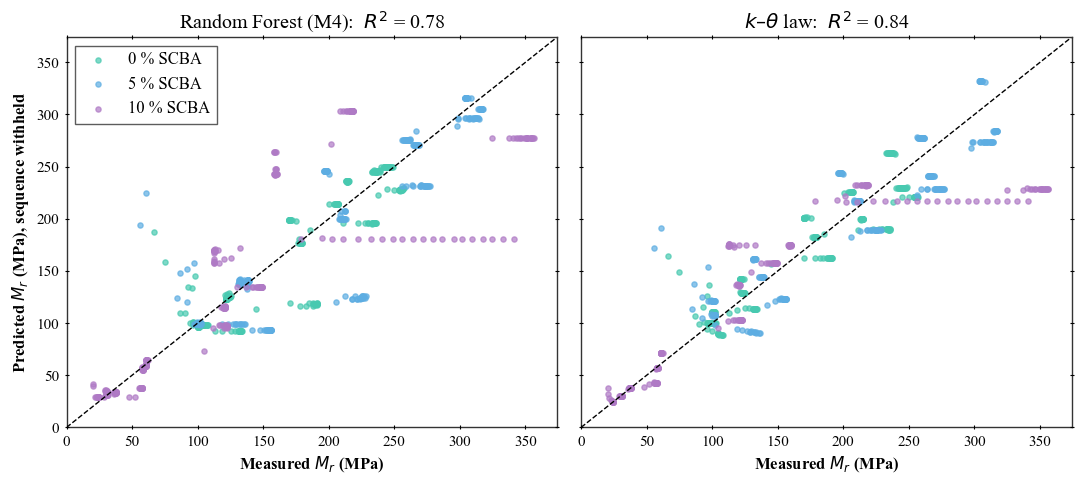

In [30]:
# =========================================================
# 8.7  PRIMARY SCHEME: LEAVE-ONE-SEQUENCE-OUT (V2) + BLOCK-BOOTSTRAP UNCERTAINTY
# =========================================================
yv = d[TARGET_COL].to_numpy()
kth_name = "k-theta law (per CBCA)"
v2_models = {
    "M4 RF (inputs known before the test)":                  rf_predict(FEATURES_M4),
    "M2 RF (+ permanent def., measured during the test)":    rf_predict(FEATURES_M2),
    kth_name:                                                kth_predict,
    "Hybrid k-theta + RF residual":                          hybrid("ktheta", BASE, RF_REG),
}
v2_pred = {}
for name, fn in v2_models.items():
    p = np.full(len(d), np.nan)
    for tr, te in LeaveOneGroupOut().split(d, groups=d[SEQ_COL]):       # 15 folds, one sequence withheld each
        p[te] = fn(d.iloc[tr], d.iloc[te])
    v2_pred[name] = p

# Uncertainty: bootstrap over the 45 blocks (the resampling unit, since rows inside a block are not independent)
rng = np.random.default_rng(SEED)
blk = d[BLOCK_COL].to_numpy(); ub = np.unique(blk)
idx_by = {b: np.where(blk == b)[0] for b in ub}
B = 2000
boot_r2 = {n: np.empty(B) for n in v2_pred}
for k in range(B):
    ii = np.concatenate([idx_by[b] for b in rng.choice(ub, size=len(ub), replace=True)])
    for n, p in v2_pred.items():
        boot_r2[n][k] = r2_score(yv[ii], p[ii])

rows = []
for n, p in v2_pred.items():
    m = reg_metrics(yv, p)
    lo, hi = np.percentile(boot_r2[n], [2.5, 97.5])
    dlt = boot_r2[n] - boot_r2[kth_name]
    rows.append({"Model": n, "R2": m["R2"], "R2 95% CI": f"[{lo:.2f}, {hi:.2f}]",
                 "RMSE (MPa)": m["RMSE"], "MAE (MPa)": m["MAE"],
                 "MAPE (%)": 100 * np.mean(np.abs(p - yv) / yv),
                 "dR2 vs k-theta [95% CI]": "-" if n == kth_name else
                     f"{np.mean(dlt):+.3f} [{np.percentile(dlt, 2.5):+.3f}, {np.percentile(dlt, 97.5):+.3f}]"})
v2_tbl = pd.DataFrame(rows)
print("=== V2 leave-one-sequence-out (15 folds, pooled predictions, 875 screened rows) ===")
print(v2_tbl.round(3).to_string(index=False))
v2_tbl.round(4).to_csv(REPORTS_DIR / "v2_primary_results.csv", index=False)

# Where does the error sit? RMSE and bias per withheld sequence (M4 vs k-theta)
per_seq = []
for s_, g_ in d.groupby(SEQ_COL):
    ix = g_.index.to_numpy()
    row = {"Sequence": int(s_), "sigma3 (kPa)": g_["Confining Stress-kPa"].median().round(1),
           "dsigma_d (kPa)": g_["Cyclic Axial Stress-kPa"].median().round(1)}
    for lab, n in [("M4", "M4 RF (inputs known before the test)"), ("k-theta", kth_name)]:
        e = v2_pred[n][ix] - yv[ix]
        row[f"{lab} RMSE"] = np.sqrt(np.mean(e ** 2)); row[f"{lab} bias"] = e.mean()
    per_seq.append(row)
print("\n=== Error per withheld sequence (MPa) ===")
print(pd.DataFrame(per_seq).round(1).to_string(index=False))

# ---- Figure 12: observed vs predicted under V2 ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lim = [0, max(yv.max(), 1) * 1.05]
for ax, (n, ttl) in zip(axes, [("M4 RF (inputs known before the test)", "Random Forest (M4)"),
                               (kth_name, r"$k$–$\theta$ law")]):
    for c, col in COLORS_SCBA.items():
        m_ = (d[SCBA_COL] == c).to_numpy()
        ax.scatter(yv[m_], v2_pred[n][m_], s=14, alpha=0.7, color=col, label=f"{c:g} % SCBA")
    ax.plot(lim, lim, "k--", linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f"{ttl}:  $R^2$ = {r2_score(yv, v2_pred[n]):.2f}")
    ax.set_xlabel("Measured $M_r$ (MPa)")
    apply_academic_spines(ax)
axes[0].set_ylabel("Predicted $M_r$ (MPa), sequence withheld")
axes[0].legend(frameon=True, edgecolor="#333333", fancybox=False)
plt.tight_layout()
export_figure(fig, FIGURES_DIR / "Figure_12_V2_Observed_vs_Predicted", dpi=300)
plt.show()

Values are for `SEED = 42`, `CLEAN_DATA = True` (875 screened readings) and are regenerated on every run.

1. **V2 is a valid and appropriate scheme for the stated objective.** With the sequence withheld, the Random Forest with inputs known before the test (M4) reaches R² ≈ 0.78 (95 % block-bootstrap CI ≈ 0.59–0.89; RMSE ≈ 39 MPa), and the variant that also uses the permanent deformation (M2) reaches R² ≈ 0.83 (CI ≈ 0.67–0.93; RMSE ≈ 34 MPa). The classical $k$–$\theta$ law gives R² ≈ 0.84 (CI ≈ 0.74–0.92; RMSE ≈ 33 MPa).
2. **The Random Forest is comparable to, not better than, the physical law.** The paired difference in R² with respect to $k$–$\theta$ is negative for the Random Forest and its 95 % interval includes zero (M4: −0.07 [−0.24, +0.05]; M2: −0.02 [−0.17, +0.10]); the hybrid is equivalent to $k$–$\theta$ (−0.003 [−0.07, +0.05]).
3. **Scope of the claim.** V2 withholds stress states, not specimens: the three specimens are present in every training fold. It supports "prediction at a stress state not tested before, for the same specimens/materials", not generalisation to new specimens (V3, R² ≈ 0.4–0.5).
4. **M2 vs M4.** M2 contains the accumulated permanent deformation, which is measured during the test; it is leakage-free with respect to the resilient cycle but is not a pre-test input. M4 is the set that answers "variables known before determining $M_r$". The advantage of M2 over M4 (and over M3 = M4 + permanent deformation, R² ≈ 0.78) was seen *after* looking at V2, so it should be presented as a sensitivity result, not as a pre-specified choice.
5. **The error is concentrated in a few stress states.** The largest biases of M4 occur when withholding sequences 4, 7 (low deviator at σ₃ = 34.5 and 68.9 kPa; under-prediction of ≈ 40–63 MPa), 9 and 11–14; see the per-sequence table.
6. **Dependence on data screening.** On all 900 readings (no screening) the V2 R² falls to ≈ 0.43 for the Random Forest and ≈ 0.23 for $k$–$\theta$ (§8.4, rows "all 900 rows"). The exclusion criteria (axial deformation reading zero; cyclic stress > 15 % off target) are objective and independent of the model, but they must be reported and confirmed against the laboratory records.

---
<a id="deployment"></a>
# 9. Deployment & Monitoring

The tuned Random Forest is serialized with `joblib` together with its predictor list, hyper-parameters and the training ranges of the inputs.
The model is valid **only inside the tested domain** (3 SCBA levels, 15 stress states of the AASHTO-type sequence); the prediction function warns when an input falls outside it.

### Production monitoring strategy
- **Data drift** — monitor the distribution of incoming features with a Kolmogorov–Smirnov two-sample test against the training distribution.
- **Concept drift** — recompute RMSE each time new laboratory tests are acquired; trigger re-training when RMSE increases beyond a predefined threshold.
- **New specimens** — new specimens (replicates per SCBA level) should be added before claiming generalisation to unseen specimens.

In [31]:
# =========================================================
# 9.1  MODEL SERIALIZATION
# =========================================================
training_ranges = {c: [float(data[c].min()), float(data[c].max())] for c in FINAL_FEATURES}
joblib.dump(best_rf, MODELS_DIR / "resilient_modulus_rf_model.pkl")
with open(MODELS_DIR / "model_card.json", "w", encoding="utf-8") as fh:
    json.dump({"features": FINAL_FEATURES,
               "hyperparameters": {k: (None if v is None else v) for k, v in final_hyperparams.items()},
               "training_ranges": training_ranges,
               "n_training_rows": int(len(X_train)),
               "validation": "GroupShuffleSplit(0.20, seed 42) by Block + GroupKFold(5)"},
              fh, indent=2, default=str)
print(f"Model and model card saved to: {MODELS_DIR}")

Model and model card saved to: c:\Users\diaz\Documents\GitHub\scba-resilient-modulus-rf\models


In [32]:
# =========================================================
# 9.2  PREDICTION INTERFACE (primary model M4 - inputs known before the test)
# =========================================================
def predict_resilient_modulus(input_features):
    """
    Predicts the axial resilient modulus (MPa) from variables known BEFORE the test.

    input_features : array-like, shape (5,)
        [% CBCA, Confining Stress-kPa, Cyclic Axial Stress-kPa, Contact Stress-kPa, theta]
    """
    import warnings
    model = joblib.load(MODELS_DIR / "resilient_modulus_rf_model.pkl")
    X_new = pd.DataFrame([input_features], columns=FINAL_FEATURES)
    for c in FINAL_FEATURES:
        lo, hi = training_ranges[c]
        if not (lo <= float(X_new[c].iloc[0]) <= hi):
            warnings.warn(f"'{c}' = {float(X_new[c].iloc[0]):.2f} is outside the training range "
                          f"[{lo:.2f}, {hi:.2f}]: extrapolation, unreliable.")
    return float(model.predict(X_new)[0])


# ---- Smoke test --------------------------------------------------
# [%CBCA, sigma3, delta_sigma_d, ContactStress, theta]
example = [5, 50, 100, 10, 3*50 + 100]
print(f"Sample prediction: {predict_resilient_modulus(example):.2f} MPa")

Sample prediction: 166.80 MPa


> **Caution (read before using 9.3).** Only three SCBA levels (0, 5, 10 %) were tested and the Random Forest is piecewise-constant in `% CBCA`: the curve below is a step function whose jumps sit between the tested levels, and the "optimum" is a tree-split artefact, not a validated optimal dosage. Leave-one-SCBA-level-out validation (V3) gives R² ≈ 0.4–0.5. Use this cell only as an illustration of the model's behaviour; do not report an optimum % SCBA from it.

      CBCA DOSAGE OPTIMIZATION & SENSITIVITY ANALYSIS RESULTS     
Optimal % CBCA (Interpolation range 0.0 - 10.0%): 2.75%
Max Predicted Resilient Modulus (Mr):          166.80 MPa
-----------------------------------------------------------------


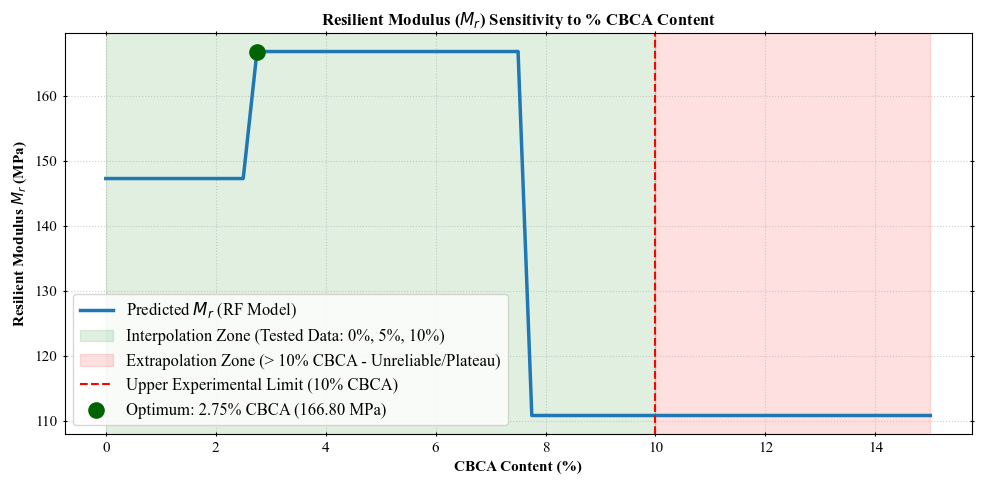

In [33]:
# =========================================================
# 9.3  SENSITIVITY ANALYSIS & DOSAGE OPTIMIZATION (INTERPOLATION VS. EXTRAPOLATION)
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_cbca_sensitivity_and_optimization(stress_state, cbca_min=0.0, cbca_max=15.0, step=0.25):
    """
    Performs a continuous sweep over % CBCA to model Resilient Modulus (Mr) response,
    identifies the optimal dosage within the interpolation range [0%, 10%],
    and highlights RF plateau behavior in the extrapolation zone (> 10%).

    stress_state : list or tuple of 4 elements
        [Confining Stress-kPa, Cyclic Axial Stress-kPa, Contact Stress-kPa, theta]
    cbca_min, cbca_max : float
        Min and max % CBCA to evaluate in the sensitivity sweep.
    step : float
        Resolution of the sweep (% CBCA increment).
    """
    model = joblib.load(MODELS_DIR / "resilient_modulus_rf_model.pkl")
    cbca_grid = np.arange(cbca_min, cbca_max + step, step)
    results = []

    for cbca in cbca_grid:
        # Reconstruct feature vector matching training schema
        feature_vector = [cbca] + list(stress_state)
        X_df = pd.DataFrame([feature_vector], columns=FINAL_FEATURES)
        
        mr_pred = float(model.predict(X_df)[0])
        region = "Interpolation" if cbca <= 10.0 else "Extrapolation"
        
        results.append({
            'CBCA_%': cbca,
            'Predicted_Mr_MPa': mr_pred,
            'Region': region
        })

    df_sweep = pd.DataFrame(results)

    # 1. Identify Optimal Dosage strictly within valid interpolation bounds [0%, 10%]
    valid_mask = df_sweep['CBCA_%'] <= 10.0
    optimal_idx = df_sweep[valid_mask]['Predicted_Mr_MPa'].idxmax()
    optimal_row = df_sweep.loc[optimal_idx]

    print("=" * 65)
    print("      CBCA DOSAGE OPTIMIZATION & SENSITIVITY ANALYSIS RESULTS     ")
    print("=" * 65)
    print(f"Optimal % CBCA (Interpolation range 0.0 - 10.0%): {optimal_row['CBCA_%']:.2f}%")
    print(f"Max Predicted Resilient Modulus (Mr):          {optimal_row['Predicted_Mr_MPa']:.2f} MPa")
    print("-" * 65)

    # 2. Visualization of Interpolation vs. Extrapolated Plateau
    plt.figure(figsize=(10, 5))
    plt.plot(df_sweep['CBCA_%'], df_sweep['Predicted_Mr_MPa'], color='#1f77b4', lw=2.5, label='Predicted $M_r$ (RF Model)')

    # Highlight zones
    plt.axvspan(0.0, 10.0, color='green', alpha=0.12, label='Interpolation Zone (Tested Data: 0%, 5%, 10%)')
    plt.axvspan(10.0, cbca_max, color='red', alpha=0.12, label='Extrapolation Zone (> 10% CBCA - Unreliable/Plateau)')
    
    # Boundary line and optimum marker
    plt.axvline(10.0, color='red', linestyle='--', linewidth=1.5, label='Upper Experimental Limit (10% CBCA)')
    plt.scatter(optimal_row['CBCA_%'], optimal_row['Predicted_Mr_MPa'], color='darkgreen', s=120, zorder=5,
                label=f"Optimum: {optimal_row['CBCA_%']:.2f}% CBCA ({optimal_row['Predicted_Mr_MPa']:.2f} MPa)")

    plt.title('Resilient Modulus ($M_r$) Sensitivity to % CBCA Content', fontsize=12, fontweight='bold')
    plt.xlabel('CBCA Content (%)', fontsize=11)
    plt.ylabel('Resilient Modulus $M_r$ (MPa)', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.show()

    return df_sweep, optimal_row


# ---- Smoke test / Example Execution ----------------------------------
# Fixed stress state: [sigma3=50, delta_sigma_d=100, ContactStress=10, theta=250]
sample_stress = [50, 100, 10, 3*50 + 100]
df_sweep, best_dosage = analyze_cbca_sensitivity_and_optimization(sample_stress, cbca_min=0.0, cbca_max=15.0, step=0.25)